# Where new scientific concepts spread next — gateway-weighted entry demo

This notebook is a runnable, scaled-down walk through **`method.py`** of the experiment *"Where new scientific concepts
spread next"* (OpenAlex full-corpus snapshot, 653 newborn concepts, 26 venue fields).

**Question (H2 entry).** When a new concept (e.g. *Anomaly detection*, *Incretin*) is born in a home field, which venue
field does it enter next? The experiment builds **concept-year risk sets** — for every concept and year, every field the
concept has not yet entered — and fits **conditional-logit** models:

| model | regressors |
|---|---|
| **M0** (baseline) | relatedness-to-home `a_phi_home`, log field size `b_log_size`, Hidalgo density `c_density`, target's own gateway centrality `e_gate_own` |
| **M1** | M0 + plain relatedness to the off-home fields that currently *retain* the concept `d0_ret_rel` |
| **M2** | M0 + **gateway-weighted** relatedness to retaining fields `d_ret_gate` |
| **M3** | M0 + both |

Relatedness comes from a frozen 26-field PMI backbone `phi`; gateway scores are its eigenvector centralities.
The pipeline also clusters concept **trajectories** (DTW k-medoids + HMM) and tests the **ordering** of the first
retained gateway field vs the entropy take-off (PELT change point).

**Protocol.** `dev` stage (CS/Eng/BGM/Med homes, t0 2003–09) → `freeze` the specification → `heldout` stage (other home
fields + 2010–14 cohort) run once with the frozen spec.

**Demo scale.** The full run used 279 dev + 374 held-out concepts. Here `mini_demo_data.json` holds a stratified
sample of **100 concepts** (56 dev, 44 held-out). The bootstrap / permutation / rewiring counts are at the **original**
values (the whole notebook runs in about 2–3 minutes); smaller values that still run are listed in the config cell.
With a fifth of the concepts, test statistics are smaller and group-level estimates noisier than in the paper; the
full-run headline numbers are shown next to the demo's at the end.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env) -- installed FIRST so the
# extra packages below resolve against Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'networkx==3.6.1', 'numba==0.60.0', 'pyarrow==18.1.0')

# loguru, tslearn (DTW), kmedoids (FasterPAM), hmmlearn, ruptures (PELT) -- NOT on Colab, always install
# (tslearn 0.6.4 instead of the artifact's 0.9.0: 0.9.0 needs numba>=0.61 and 0.7-0.8 fail to compile DTW masks
#  under Colab's numba 0.60; 0.6.4 pins numpy<2.3, scikit-learn<1.7, scipy<1.17, numba<0.62 = Colab's stack)
_pip('loguru==0.7.3', 'tslearn==0.6.4', 'kmedoids==0.5.5', 'hmmlearn==0.3.3', 'ruptures==1.1.10')

## Imports

The original import block of `method.py`. The artifact's helper modules (`config`, `stats_core`, `h2`, `traj`, ...)
live in a `lib/` folder; the notebook re-creates that folder below with `%%writefile` cells, so the `lib` imports
(`import h2 as H2`, ...) happen after those cells.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import resource
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

import matplotlib.pyplot as plt  # notebook addition: result plots

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
(ROOT / "lib").mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT / "lib"))

## Data loading

`mini_demo_data.json` contains
* `examples` — 100 concepts, each a row of the original `results/frame_concepts.csv` (split, group, home field(s), onset
  year `t0`, outcomes such as `O1`, `O2r_resid`, ...) plus **`g`**: its grounded work counts per year × venue field,
  a `[28 years (1995–2022) × 27 slots]` array (slot 0 = no venue field, slot k = OpenAlex field 10+k);
* `backbone` — the frozen 26×26 PMI relatedness matrix `phi` and gateway centralities (eigenvector/degree/betweenness);
* `GF` — all-corpus works per year × field (field sizes);
* `reference_full_run` — headline numbers of the full run, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_-IpcIodNqp66/round-2/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["examples"]), "concepts;", pd.Series([e["split"] for e in data["examples"]]).value_counts().to_dict())

100 concepts; {'dev': 56, 'heldout_field': 33, 'heldout_cohort': 11}


## Configuration

All resampling counts that drive runtime, set to the artifact's original values. `method.py` read the first three
from `config.py` (env-overridable); the others were hard-coded inside functions and are exposed here instead. Lower
them (down to the "minimum that runs" in the comments) for a quick smoke test.
`RUN_RESCUE_RELAY` is off: the rescue/relay analyses need the work-level citation corpus (millions of OpenAlex works),
which does not fit in a demo file.

In [5]:
N_BOOT = 2000    # original: 2000; minimum that runs: 2
N_PERM = 1000    # original: 1000; minimum that runs: 2
N_REWIRE = 200     # original: 200; minimum that runs: 2
N_PLANTED_NULL = 100     # original: 100; minimum that runs: 2
N_PLANTED_POS = 10      # original: 10; minimum that runs: 1
N_PLACEBO = 200     # original: 200; minimum that runs: 2
N_CHOOSEK_BOOT = 100     # original: 100; minimum that runs: 2
N_SHUF = 200     # original: 200; minimum that runs: 20
N_GROUP_BOOT = 500     # original: 500; minimum that runs: 2
RUN_RESCUE_RELAY = False  # original: True (needs work-level OpenAlex provenance tables, not in the demo data)

## `lib/config.py` — frozen constants

Field ids 11–36 (26 OpenAlex fields), years 1995–2022, the dev home fields and the held-out field groups.
Only change: every output directory points to `demo_results/`. (`N_BOOT`/`N_PERM`/`N_REWIRE` defined here are not
used — the notebook's config cell takes precedence.)

In [6]:
%%writefile lib/config.py
"""Frozen constants and paths shared by every module (paths derived from this file's location)."""
from __future__ import annotations

import os
from pathlib import Path

ROOT = Path(__file__).resolve().parent
# demo: all outputs go to demo_results/ (original: inputs/, results/, logs/, figures/, scan/, benchmark/)
INP = RES = LOGS = FIGS = SCAN = BENCH = ROOT.parent / "demo_results"
RES.mkdir(parents=True, exist_ok=True)
P1 = SCAN / "pass1"
P2 = SCAN / "pass2"

SEED = 20261001
FIELDS = list(range(11, 37))
NF = 26
Y0, Y1 = 1995, 2022
NY = Y1 - Y0 + 1
DEV_HOME = {17: "CS", 22: "Eng", 13: "BGM", 27: "Med"}
HELDOUT_GROUP = {"Physical": [15, 16, 21, 25, 31], "LifeEnv": [11, 19, 23, 24, 28, 30],
                 "Social": [12, 14, 20, 32, 33], "MathDec": [18, 26], "OtherHealth": [29, 34, 35, 36]}
FIELD_GROUP = {f: g for g, fs in HELDOUT_GROUP.items() for f in fs}
FIELD_GROUP.update({f: "DEV_" + s for f, s in DEV_HOME.items()})
M_RAREFY, M_RAREFY_SENS = 30, 50
EPISODE_MIN = 2
RET_MIN = 2
T0_MIN = 20
TAG_SCORE = 0.3
PREC_GATE = 0.8
N_BOOT = int(os.environ.get("AII_NBOOT", 2000))  # env overrides only for debugging runs
N_PERM = int(os.environ.get("AII_NPERM", 1000))
N_REWIRE = int(os.environ.get("AII_NREWIRE", 200))
OPENROUTER_CAP_USD = 0.50

Overwriting lib/config.py


## `lib/stats_core.py` — estimators (verbatim)

* `CLogit` — vectorised conditional logit (one stratum = one concept-year; Breslow form for several entries per stratum);
* `fe_ols` — OLS with fixed effects swept out and concept-clustered (CRV1) SEs;
* `fe_poisson`, `dersimonian_laird` (random-effects pooling across held-out groups), `sign_test`.

In [7]:
%%writefile lib/stats_core.py
"""Estimators: vectorised conditional logit (Breslow form for multiple events per stratum), within-FE OLS with
cluster-robust (CRV1) SEs, Poisson with concept FE, DerSimonian-Laird random-effects pooling, sign test."""
from __future__ import annotations

import math

import numpy as np
from scipy import optimize, stats


class CLogit:
    """Each event row e in stratum s contributes x_e.b - log sum_{i in s} exp(x_i.b).
    Rows must be sorted by stratum; `starts` are the first row index of each stratum."""

    def __init__(self, X: np.ndarray, y: np.ndarray, strata: np.ndarray, ridge: float = 0.0):
        o = np.argsort(strata, kind="stable")
        self.X, self.y, self.s = X[o].astype(float), y[o].astype(float), strata[o]
        self.order = o
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        keep_s = (self.nev > 0) & (self.nev < self.counts)  # informative strata only
        rows = np.repeat(keep_s, self.counts)
        self.X, self.y, self.s = self.X[rows], self.y[rows], self.s[rows]
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        self.ridge = ridge

    def nll(self, b: np.ndarray) -> tuple[float, np.ndarray]:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        mm = np.repeat(m, self.counts)
        w = np.exp(eta - mm)
        S = np.add.reduceat(w, self.starts)
        lse = np.log(S) + m
        ll = float((self.y * eta).sum() - (self.nev * lse).sum())
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)  # per stratum expectation
        g = (self.y[:, None] * self.X).sum(0) - (self.nev[:, None] * Ex).sum(0)
        ll -= 0.5 * self.ridge * float(b @ b)
        g = g - self.ridge * b
        return -ll, -g

    def hessian(self, b: np.ndarray) -> np.ndarray:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        w = np.exp(eta - np.repeat(m, self.counts))
        S = np.add.reduceat(w, self.starts)
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
        Exx = np.add.reduceat(p[:, None, None] * (self.X[:, :, None] * self.X[:, None, :]), self.starts)
        cov = Exx - Ex[:, :, None] * Ex[:, None, :]
        return (self.nev[:, None, None] * cov).sum(0) + self.ridge * np.eye(len(b))

    def fit(self) -> dict:
        k = self.X.shape[1]
        if len(self.starts) == 0:
            return {"coef": np.full(k, np.nan), "se": np.full(k, np.nan), "ll": np.nan, "n_strata": 0, "converged": False}
        r = optimize.minimize(self.nll, np.zeros(k), jac=True, method="L-BFGS-B", options={"maxiter": 500, "gtol": 1e-8})
        H = self.hessian(r.x)
        try:
            se = np.sqrt(np.diag(np.linalg.inv(H)))
        except np.linalg.LinAlgError:
            se = np.full(k, np.nan)
        return {"coef": r.x, "se": se, "ll": -r.fun, "n_strata": int(len(self.starts)), "n_events": int(self.y.sum()),
                "n_rows": int(len(self.y)), "converged": bool(r.success)}


def ll_null_clogit(y: np.ndarray, strata: np.ndarray) -> float:
    """log-likelihood at b = 0 on informative strata."""
    _, inv, cnt = np.unique(strata, return_inverse=True, return_counts=True)
    nev = np.bincount(inv, weights=y)
    keep = (nev > 0) & (nev < cnt)
    return float(-(nev[keep] * np.log(cnt[keep])).sum())


def demean(A: np.ndarray, groups: list[np.ndarray], iters: int = 50, tol: float = 1e-10) -> np.ndarray:
    """Alternating projections to sweep out several sets of fixed effects."""
    A = A.astype(float).copy()
    if A.ndim == 1:
        A = A[:, None]
    for _ in range(iters if len(groups) > 1 else 1):
        prev = A.copy()
        for g in groups:
            _, inv = np.unique(g, return_inverse=True)
            cnt = np.bincount(inv)
            for j in range(A.shape[1]):
                A[:, j] -= (np.bincount(inv, weights=A[:, j]) / cnt)[inv]
        if len(groups) > 1 and np.abs(A - prev).max() < tol:
            break
    return A


def fe_ols(y: np.ndarray, X: np.ndarray, fe: list[np.ndarray], cluster: np.ndarray, names: list[str]) -> dict:
    """OLS of y on X after sweeping out fixed effects `fe`; CRV1 SEs clustered on `cluster` (small-sample corrected)."""
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, cluster = y[ok], X[ok], cluster[ok]
    fe = [g[ok] for g in fe]
    Z = demean(np.column_stack([y, X]), fe) if fe else np.column_stack([y - y.mean(), X - X.mean(0)])
    yd, Xd = Z[:, 0], Z[:, 1:]
    XtX = Xd.T @ Xd
    try:
        XtXi = np.linalg.pinv(XtX)
    except np.linalg.LinAlgError:
        return {"error": "singular"}
    b = XtXi @ Xd.T @ yd
    e = yd - Xd @ b
    _, cinv = np.unique(cluster, return_inverse=True)
    G = cinv.max() + 1
    sc = np.zeros((G, Xd.shape[1]))
    np.add.at(sc, cinv, Xd * e[:, None])
    n, k = Xd.shape
    corr = G / max(G - 1, 1) * (n - 1) / max(n - k, 1)
    V = corr * XtXi @ (sc.T @ sc) @ XtXi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    tcrit = stats.t.ppf(0.975, max(G - 1, 1))
    out = {"n": int(n), "n_clusters": int(G), "coef": {}, "V": V.tolist()}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - tcrit * se[i]), float(b[i] + tcrit * se[i])],
                           "p": float(2 * stats.t.sf(abs(b[i] / se[i]), max(G - 1, 1))) if se[i] > 0 else float("nan")}
    out["_b"] = b
    return out


def fe_poisson(y: np.ndarray, X: np.ndarray, group: np.ndarray, names: list[str], offset: np.ndarray | None = None,
               iters: int = 100) -> dict:
    """Poisson with group fixed effects (concentrated out: exp(alpha_g) = sum y / sum exp(xb+off) within g),
    Newton on b; CRV1 sandwich SEs clustered by group."""
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, group = y[ok].astype(float), X[ok].astype(float), group[ok]
    off = np.zeros(len(y)) if offset is None else offset[ok]
    _, gi = np.unique(group, return_inverse=True)
    sy = np.bincount(gi, weights=y)
    keep = sy[gi] > 0  # groups with all-zero outcomes carry no information
    y, X, off, gi = y[keep], X[keep], off[keep], gi[keep]
    _, gi = np.unique(gi, return_inverse=True)
    sy = np.bincount(gi, weights=y)
    b = np.zeros(X.shape[1])
    for _ in range(iters):
        eta = X @ b + off
        w = np.exp(eta - eta.max())
        sw = np.bincount(gi, weights=w)
        mu = w * (sy / sw)[gi]
        # concentrated score / hessian: X demeaned by mu-weighted group means
        xm = np.column_stack([np.bincount(gi, weights=mu * X[:, j]) / np.bincount(gi, weights=mu) for j in range(X.shape[1])])[gi]
        Xc = X - xm
        g = Xc.T @ (y - mu)
        H = (Xc * mu[:, None]).T @ Xc
        step = np.linalg.solve(H + 1e-10 * np.eye(len(b)), g)
        b = b + step
        if np.abs(step).max() < 1e-9:
            break
    Hi = np.linalg.pinv(H)
    sc = np.zeros((gi.max() + 1, X.shape[1]))
    np.add.at(sc, gi, Xc * (y - mu)[:, None])
    G = gi.max() + 1
    V = G / max(G - 1, 1) * Hi @ (sc.T @ sc) @ Hi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    out = {"n": int(len(y)), "n_clusters": int(G), "coef": {}}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - 1.96 * se[i]), float(b[i] + 1.96 * se[i])],
                           "p": float(2 * stats.norm.sf(abs(b[i] / se[i]))) if se[i] > 0 else float("nan")}
    return out


def dersimonian_laird(b: np.ndarray, se: np.ndarray) -> dict:
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    C = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if k > 1 and C > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def sign_test(k_pos: int, n: int) -> float:
    """one-sided binomial P(X >= k_pos | p = 0.5)."""
    return float(stats.binom.sf(k_pos - 1, n, 0.5)) if n > 0 else float("nan")

Overwriting lib/stats_core.py


## `lib/h2.py` — field-state machine and entry risk sets (verbatim)

* `states` — per concept and year: which fields are **entered** (cumulative ≥2 works), **retaining** (entered ≥2 years
  ago and ≥2 works in the last 3 years, off-home) or **lost**;
* `build_risk_sets` — one row per (concept, year t, candidate field k) with the regressors, e.g.
  `d_ret_gate = Σ_{j∈Ret(t-1)} g_j·phi[j,k] / Σ g_j`;
* `fit_model`, `lr_test`, `within_auc` (per-stratum AUC), bootstrap helpers, and the nulls: `recompute_d` (label
  permutation) and `rewire` + `eig_gateway` (degree-preserving rewired backbone).

In [8]:
%%writefile lib/h2.py
"""H2 next-field entry: field-year state machine, concept-year risk sets, conditional-logit blocks, AUCs, placebos."""
from __future__ import annotations

import math

import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats

from config import Y0
from stats_core import CLogit, fe_ols

REG = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"]
MODELS = {"M0": ["a_phi_home", "b_log_size", "c_density", "e_gate_own"],
          "M1": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel"],
          "M2": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_ret_gate"],
          "M3": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"],
          "M2lost": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_lost_gate"]}


def states(g: np.ndarray, home: list[int], min_n: int = 2) -> dict:
    """g: [NY, 27] grounded counts. Returns boolean [NY, 26] matrices (years Y0..)."""
    x = g[:, 1:]
    cum = np.cumsum(x, 0)
    entered = cum >= min_n
    w3 = x.copy()
    w3[1:] += x[:-1]; w3[2:] += x[:-2]
    ent_lag2 = np.zeros_like(entered); ent_lag2[2:] = entered[:-2]
    offhome = np.ones(26, bool)
    for h in home:
        offhome[h - 11] = False
    retaining = ent_lag2 & (w3 >= min_n) & offhome[None, :]
    lost = entered & (w3 == 0)
    return {"entered": entered, "retaining": retaining, "lost": lost, "w3": w3, "cum": cum, "offhome": offhome}


def rca_entered(g: np.ndarray, GF: np.ndarray) -> np.ndarray:
    """entry when cumulative count >= 2 and the field's cumulative share of the concept exceeds its share of all works."""
    x = np.cumsum(g[:, 1:], 0)
    tot = x.sum(1, keepdims=True)
    F = np.cumsum(GF, 0)
    share_all = F / np.maximum(F.sum(1, keepdims=True), 1)
    share_c = x / np.maximum(tot, 1)
    ok = (x >= 2) & (share_c > share_all)
    return np.maximum.accumulate(ok.astype(int), 0).astype(bool)


def build_risk_sets(frame: pd.DataFrame, G: dict[int, np.ndarray], bb: dict, GF: np.ndarray,
                    entry_def: str = "count", horizon: int = 8) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Rows = (concept, year t, candidate field k not entered by t-1, not home). Returns df, Ret matrix, Lost matrix."""
    phi, gate = bb["phi"], bb["g"]
    colsum = phi.sum(0)
    logGF = np.log(np.maximum(GF, 1))
    rows, RET, LOST = [], [], []
    for r in frame.itertuples():
        c = int(r.cidx); t0 = int(r.t0)
        home = [int(h) for h in str(r.home).split("|")]
        S = states(G[c], home)
        ent = rca_entered(G[c], GF) if entry_def == "rca" else S["entered"]
        hidx = [h - 11 for h in home]
        a = phi[hidx].mean(0)
        for t in range(t0 + 1, min(t0 + horizon, 2022) + 1):
            ti = t - Y0
            E = ent[ti - 1]
            cand = ~E & S["offhome"]
            if not cand.any():
                continue
            ev = ent[ti] & cand
            Ret = S["retaining"][ti - 1]
            Lost = S["lost"][ti - 1] & S["offhome"]
            dens = (phi[E].sum(0)) / np.where(colsum > 0, colsum, 1)
            d0 = phi[Ret].mean(0) if Ret.any() else np.zeros(26)
            d = (gate[Ret] @ phi[Ret]) / gate[Ret].sum() if Ret.any() and gate[Ret].sum() > 0 else np.zeros(26)
            dl = (gate[Lost] @ phi[Lost]) / gate[Lost].sum() if Lost.any() and gate[Lost].sum() > 0 else np.zeros(26)
            for k in np.nonzero(cand)[0]:
                rows.append((c, t, t - t0, k + 11, int(ev[k]), a[k], logGF[ti - 1, k], dens[k], gate[k], d0[k], d[k], dl[k],
                             int(Ret.sum()), int(Lost.sum()), r.group, r.split, int(r.intersection_born), float(r.home_gateway)))
                RET.append(Ret); LOST.append(Lost)
    df = pd.DataFrame(rows, columns=["cidx", "t", "age", "field", "entered", "a_phi_home", "b_log_size", "c_density",
                                     "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "n_ret", "n_lost", "group",
                                     "split", "intersection_born", "home_gateway"])
    df["stratum"] = df.cidx.astype(np.int64) * 100 + (df.t - 2000)
    return df, np.array(RET, bool).reshape(-1, 26), np.array(LOST, bool).reshape(-1, 26)


def standardise(df: pd.DataFrame, spec: dict | None, cols: list[str]) -> tuple[pd.DataFrame, dict]:
    if spec is None:
        spec = {c: {"mean": float(df[c].mean()), "sd": float(df[c].std() or 1.0)} for c in cols}
    out = df.copy()
    for c in cols:
        out[c] = (df[c] - spec[c]["mean"]) / (spec[c]["sd"] if spec[c]["sd"] > 0 else 1.0)
    return out, spec


def fit_model(df: pd.DataFrame, cols: list[str], ridge: float = 0.0) -> dict:
    m = CLogit(df[cols].to_numpy(), df.entered.to_numpy(), df.stratum.to_numpy(), ridge=ridge).fit()
    return {"coef": dict(zip(cols, map(float, m["coef"]))), "se": dict(zip(cols, map(float, m["se"]))), "ll": m["ll"],
            "n_strata": m["n_strata"], "n_events": m.get("n_events", 0), "n_rows": m.get("n_rows", 0),
            "converged": m["converged"], "_b": m["coef"]}


def lr_test(big: dict, small: dict, df_: int) -> dict:
    lr = 2 * (big["ll"] - small["ll"])
    return {"LR": float(lr), "df": df_, "p": float(stats.chi2.sf(max(lr, 0), df_))}


def within_auc(df: pd.DataFrame, score: np.ndarray) -> pd.Series:
    """mean-rank AUC per informative stratum."""
    d = pd.DataFrame({"s": df.stratum.to_numpy(), "y": df.entered.to_numpy(), "x": score})
    d["r"] = d.groupby("s").x.rank(method="average")
    g = d.groupby("s").agg(ntot=("y", "size"), nev=("y", "sum"))
    re = d[d.y == 1].groupby("s").r.sum()
    g = g.join(re.rename("rs")).fillna({"rs": 0})
    g = g[(g.nev > 0) & (g.nev < g.ntot)]
    nn = g.ntot - g.nev
    return (g.rs - g.nev * (g.nev + 1) / 2) / (g.nev * nn)


def concept_boot_mean(series: pd.Series, n_boot: int, rng) -> list[float]:
    """series indexed by stratum id (cidx*100 + ...): concept-clustered bootstrap CI of the mean."""
    cid = (series.index.to_numpy() // 100)
    u, inv = np.unique(cid, return_inverse=True)
    sums = np.bincount(inv, weights=series.to_numpy()); cnts = np.bincount(inv)
    bs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(u), len(u))
        bs.append(sums[pick].sum() / max(cnts[pick].sum(), 1))
    return [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]


def boot_coef(df: pd.DataFrame, cols: list[str], target: str, n_boot: int, rng, small_cols: list[str] | None = None) -> dict:
    """concept-clustered bootstrap of a clogit coefficient (and the LR vs small model if given)."""
    cids = df.cidx.unique()
    by = {c: ix for c, ix in df.groupby("cidx").indices.items()}
    X = df[cols].to_numpy(); y = df.entered.to_numpy(); st = df.stratum.to_numpy()
    Xs = df[small_cols].to_numpy() if small_cols else None
    bs, lrs = [], []
    for b in range(n_boot):
        pick = rng.choice(cids, len(cids))
        idx = np.concatenate([by[c] for c in pick])
        rep = np.repeat(np.arange(len(pick)), [len(by[c]) for c in pick])
        s2 = st[idx] * 10000 + rep  # relabel strata of repeated concepts
        m = CLogit(X[idx], y[idx], s2).fit()
        bs.append(m["coef"][cols.index(target)])
        if small_cols:
            ms = CLogit(Xs[idx], y[idx], s2).fit()
            lrs.append(2 * (m["ll"] - ms["ll"]))
    bs = np.array(bs)
    out = {"ci": [float(np.nanpercentile(bs, 2.5)), float(np.nanpercentile(bs, 97.5))], "se_boot": float(np.nanstd(bs)),
           "n_boot": n_boot}
    if small_cols:
        out["lr_boot"] = [float(x) for x in np.percentile(lrs, [5, 25, 50, 75, 95])]
        out["_lrs"] = np.array(lrs)
    return out


def recompute_d(RET: np.ndarray, fields: np.ndarray, phi: np.ndarray, gate: np.ndarray) -> np.ndarray:
    k = fields - 11
    w = RET * gate[None, :]
    den = w.sum(1)
    num = (w * phi[:, k].T).sum(1)
    return np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)


def eig_gateway(phi: np.ndarray) -> np.ndarray:
    Gx = nx.from_numpy_array(phi)
    try:
        ev = nx.eigenvector_centrality_numpy(Gx, weight="weight")
    except Exception:  # noqa: BLE001 -- disconnected graph after rewiring: fall back to power iteration
        ev = nx.eigenvector_centrality(Gx, weight="weight", max_iter=2000)
    v = np.array([ev[i] for i in range(len(phi))])
    v = np.abs(v)
    return v / v.max()


def rewire(phi: np.ndarray, rng) -> np.ndarray:
    """degree-preserving double-edge swaps on the phi>0 graph; original weights reassigned at random to the new edges."""
    Gx = nx.Graph()
    Gx.add_nodes_from(range(len(phi)))
    iu = np.transpose(np.nonzero(np.triu(phi, 1) > 0))
    Gx.add_edges_from(map(tuple, iu))
    ne = Gx.number_of_edges()
    try:
        nx.double_edge_swap(Gx, nswap=10 * ne, max_tries=1000 * ne, seed=int(rng.integers(1 << 31)))
    except nx.NetworkXAlgorithmError:
        pass
    w = phi[iu[:, 0], iu[:, 1]].copy()
    rng.shuffle(w)
    P = np.zeros_like(phi)
    for (i, j), wt in zip(Gx.edges(), w):
        P[i, j] = P[j, i] = wt
    return P

Overwriting lib/h2.py


## `lib/lib_outcomes.py` and `lib/traj.py` — trajectories and ordering (verbatim)

`traj.py` builds a 9-year panel per concept (fields entered / retaining / lost, rarefied richness `R20`, Shannon
entropy `H`, gateway share, volume), clusters the z-scored series with DTW k-medoids (k chosen by silhouette among
bootstrap-stable solutions) and a Gaussian HMM, and runs the **ordering** test: does the first retained *gateway*
field precede the calibrated PELT change point in entropy?

In [9]:
%%writefile lib/lib_outcomes.py
"""S1/S0 primitives copied from iteration 1 (gen_art_experiment_4 features.py / s0_ground.py / s0_labels.py),
adapted to integer field ids and numpy yearly arrays."""
from __future__ import annotations

import math

import numpy as np
from scipy.special import gammaln


def rarefied_richness(counts, m: int) -> float:
    """Exact hypergeometric rarefaction E[S_m] = sum_j 1 - C(N-n_j, m)/C(N, m)  (verbatim logic)."""
    n = np.asarray([c for c in counts if c > 0], dtype=float)
    N = n.sum()
    if N < m:
        return math.nan
    lc = lambda a, b: gammaln(a + 1) - gammaln(b + 1) - gammaln(a - b + 1)  # noqa: E731
    out = 0.0
    for nj in n:
        out += 1.0 if N - nj < m else 1.0 - math.exp(lc(N - nj, m) - lc(N, m))
    return out


def shannon(v) -> float:
    v = np.asarray([x for x in v if x > 0], dtype=float)
    if v.sum() == 0:
        return math.nan
    p = v / v.sum()
    return float(-(p * np.log(p)).sum())


def onset(yc: dict[int, float]) -> tuple[float, bool | None]:
    """t0 = first year 2000..2014 with >= 20 works; newborn = each of t0-3..t0-1 < 0.25 * n(t0+2)."""
    ts = [y for y in range(2000, 2015) if yc.get(y, 0) >= 20]
    if not ts:
        return math.nan, None
    t0 = ts[0]
    newborn = all(yc.get(t0 - k, 0) < 0.25 * yc.get(t0 + 2, 0) for k in (1, 2, 3))
    return float(t0), newborn


def home_of(fc: dict[int, float]) -> tuple[list[int], bool]:
    """home = fields with >= 40% share, else the top field (flagged weak)."""
    tot = sum(fc.values())
    if not tot:
        return [], True
    h = [f for f, n in fc.items() if n / tot >= 0.40]
    if h:
        return sorted(h, key=lambda f: -fc[f]), False
    return [max(fc, key=fc.get)], True


def outcomes(yc: dict, gtot: dict, t0: int, fcD) -> dict:
    """O1 sustained share uptake, O3 transience, O2r rarefied venue-field richness in t0+6..t0+8 (verbatim logic)."""
    sh = lambda y: yc.get(y, 0) / gtot[y]  # noqa: E731
    o1 = int(np.mean([sh(y) for y in range(t0 + 6, t0 + 9)]) >= sh(t0 + 5))
    seq = [yc.get(y, 0) for y in range(t0, t0 + 9)]
    peak_y = t0 + int(np.argmax(seq))
    late = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
    o3 = int(t0 + 3 <= peak_y <= t0 + 8 and max(seq) / max(late, 1e-9) >= 2)
    counts = [int(round(x)) for x in fcD]
    N = int(sum(counts))
    return {"O1": o1, "O3": o3, "peak_year": peak_y, "N_outcome": N, "O2r_m30": rarefied_richness(counts, 30),
            "O2r_m50": rarefied_richness(counts, 50), "O2_raw": int(sum(1 for c in counts if c >= 15))}

Overwriting lib/lib_outcomes.py


In [10]:
%%writefile lib/traj.py
"""RQ2 trajectories (DTW k-medoids + Gaussian HMM, k by silhouette and bootstrap ARI) and the ordering test
(calibrated change-point for entropy take-off vs first retained gateway field; lead-lag panels)."""
from __future__ import annotations

import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats

from config import Y0
from h2 import states
from lib_outcomes import rarefied_richness, shannon
from stats_core import fe_ols

VARS = ["n_entered_offhome", "n_retaining", "n_lost", "R20", "H", "G_share", "log_volume"]


def concept_series(g: np.ndarray, t0: int, home: list[int], gate: np.ndarray, top: np.ndarray, bot: np.ndarray) -> pd.DataFrame:
    S = states(g, home)
    rows = []
    for t in range(t0, t0 + 9):
        ti = t - Y0
        win = g[max(ti - 2, 0):ti + 1, 1:].sum(0)
        off = S["offhome"]
        tot = win.sum()
        rows.append({"t": t, "age": t - t0, "n_entered_offhome": int((S["entered"][ti] & off).sum()),
                     "n_retaining": int(S["retaining"][ti].sum()), "n_lost": int((S["lost"][ti] & off).sum()),
                     "R20": rarefied_richness(np.round(win).astype(int), 20), "H": shannon(win),
                     "G_share": float((win * off * gate).sum() / tot) if tot else np.nan,
                     "log_volume": math.log1p(g[ti].sum()),
                     "ret_gw": int((S["retaining"][ti] & top).sum()), "ret_per": int((S["retaining"][ti] & bot).sum())})
    df = pd.DataFrame(rows)
    for v in ("R20", "H", "G_share"):
        df[v] = df[v].ffill().bfill().fillna(0 if v != "R20" else 1.0)
    return df


def panel(frame: pd.DataFrame, G: dict, gate: np.ndarray, top: np.ndarray, bot: np.ndarray) -> pd.DataFrame:
    out = []
    for r in frame.itertuples():
        home = [int(h) for h in str(r.home).split("|")]
        s = concept_series(G[int(r.cidx)], int(r.t0), home, gate, top, bot)
        s.insert(0, "cidx", int(r.cidx))
        out.append(s)
    return pd.concat(out, ignore_index=True)


def to_array(P: pd.DataFrame, zspec: dict) -> tuple[np.ndarray, np.ndarray]:
    ids = P.cidx.unique()
    Z = np.stack([((P[P.cidx == c][VARS] - pd.Series({v: zspec[v][0] for v in VARS})) /
                   pd.Series({v: zspec[v][1] for v in VARS})).to_numpy() for c in ids])
    return ids, Z


def dtw_matrix(Z: np.ndarray) -> np.ndarray:
    from tslearn.metrics import cdist_dtw
    return cdist_dtw(Z, global_constraint="sakoe_chiba", sakoe_chiba_radius=2, n_jobs=4)


def kmed(D: np.ndarray, k: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    import kmedoids
    r = kmedoids.fasterpam(D, k, random_state=seed, max_iter=300, init="build")
    # demo fix: kmedoids returns uint64 labels, which np.bincount rejects under Colab's numpy 2.0
    return np.asarray(r.labels).astype(np.int64), np.asarray(r.medoids).astype(np.int64)


def choose_k(D: np.ndarray, seed: int, ks=range(2, 9), n_boot: int = 100) -> dict:
    from sklearn.metrics import adjusted_rand_score, silhouette_score
    rng = np.random.default_rng(seed)
    n = len(D)
    res = {}
    for k in ks:
        if k >= n:
            break
        lab, med = kmed(D, k, seed)
        sil = float(silhouette_score(D, lab, metric="precomputed")) if len(set(lab)) > 1 else float("nan")
        aris = []
        for b in range(n_boot):
            idx = np.sort(rng.choice(n, int(0.8 * n), replace=False))
            lb, _ = kmed(D[np.ix_(idx, idx)], k, seed + b + 1)
            aris.append(adjusted_rand_score(lab[idx], lb))
        res[k] = {"silhouette": sil, "ari_median": float(np.median(aris)), "ari_p10": float(np.percentile(aris, 10)),
                  "sizes": np.bincount(lab).tolist()}
    ok = [k for k, v in res.items() if v["ari_median"] >= 0.6]
    if ok:
        kbest = max(ok, key=lambda k: res[k]["silhouette"]); flag = "stable"
    else:
        kbest = 2; flag = "unstable"
    return {"grid": res, "k": kbest, "flag": flag}


def hmm_fit(Z: np.ndarray, seed: int, n_states=range(2, 7)) -> dict:
    from hmmlearn.hmm import GaussianHMM
    X = Z.reshape(-1, Z.shape[2]); L = [Z.shape[1]] * Z.shape[0]
    best = None; grid = {}
    for s in n_states:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = GaussianHMM(n_components=s, covariance_type="diag", n_iter=200, random_state=seed).fit(X, L)
        ll = m.score(X, L)
        p = s * (s - 1) + (s - 1) + 2 * s * Z.shape[2]
        bic = -2 * ll + p * math.log(len(X))
        grid[s] = {"ll": float(ll), "bic": float(bic)}
        if best is None or bic < best[1]:
            best = (s, bic, m)
    s, _, m = best
    paths = np.stack([m.predict(z) for z in Z])
    return {"grid": grid, "n_states": s, "paths": paths, "model": m,
            "means": m.means_.tolist(), "transmat": m.transmat_.tolist()}


def collapse(path: np.ndarray) -> str:
    out = [int(path[0])]
    for x in path[1:]:
        if int(x) != out[-1]:
            out.append(int(x))
    return "-".join(map(str, out))


# ------------------------------------------------------------------ ordering
def first_upward_change(h: np.ndarray, pen: float) -> int | None:
    import ruptures as rpt
    x = np.asarray(h, float)
    sd = x.std()
    if sd == 0 or len(x) < 4:
        return None
    x = (x - x.mean()) / sd
    bps = rpt.Pelt(model="l2", min_size=2, jump=1).fit(x.reshape(-1, 1)).predict(pen=pen)
    prev = 0
    for b in bps[:-1]:
        nxt = bps[bps.index(b) + 1]
        if x[b:nxt].mean() > x[prev:b].mean():
            return b
        prev = b
    return None


def calibrate_pen(series: list[np.ndarray], seed: int, target: float = 0.05, n_shuf: int = 200) -> dict:
    rng = np.random.default_rng(seed)
    shuf = []
    for _ in range(n_shuf):
        s = series[rng.integers(len(series))]
        shuf.append(rng.permutation(s))
    grid = np.round(np.concatenate([np.linspace(0.5, 6, 23), np.linspace(6.5, 20, 10)]), 3)
    far = {float(p): float(np.mean([first_upward_change(s, p) is not None for s in shuf])) for p in grid}
    ok = [p for p, f in far.items() if f <= target]
    pen = min(ok) if ok else max(far)
    # fresh shuffles to check the achieved rate
    fresh = [rng.permutation(series[rng.integers(len(series))]) for _ in range(n_shuf)]
    far_fresh = float(np.mean([first_upward_change(s, pen) is not None for s in fresh]))
    return {"pen": float(pen), "far_grid": far, "far_fresh": far_fresh}


def ordering(P: pd.DataFrame, frame: pd.DataFrame, pen: float, top_o2r: set[int]) -> dict:
    rows = []
    for c, d in P.groupby("cidx"):
        d = d.sort_values("t")
        b = first_upward_change(d.H.to_numpy(), pen)
        tau = int(d.t.iloc[b]) if b is not None else None
        gw = d[d.ret_gw > 0].t; pe = d[d.ret_per > 0].t
        rows.append({"cidx": c, "tau": tau, "gamma": int(gw.iloc[0]) if len(gw) else None,
                     "pi": int(pe.iloc[0]) if len(pe) else None, "top_o2r": c in top_o2r})
    O = pd.DataFrame(rows)
    T = O[O.top_o2r]

    def share(col: str) -> dict:
        d = T[T.tau.notna() & T[col].notna()]
        before = int((d[col] < d.tau).sum()); ties = int((d[col] == d.tau).sum()); after = int((d[col] > d.tau).sum())
        n = before + after
        return {"n_evaluable": int(len(d)), "before": before, "ties": ties, "after": after,
                "share_before_excl_ties": before / n if n else float("nan"),
                "sign_test_p_one_sided": float(stats.binom.sf(before - 1, n, 0.5)) if n else float("nan")}
    res = {"n_top_o2r": int(len(T)), "n_tau_detected": int(T.tau.notna().sum()),
           "share_tau_detected": float(T.tau.notna().mean()) if len(T) else float("nan"),
           "gateway": share("gamma"), "peripheral": share("pi")}
    # paired McNemar on concepts with both gamma and pi evaluable
    d = T[T.tau.notna() & T.gamma.notna() & T.pi.notna()]
    a = (d.gamma < d.tau).astype(int); b = (d.pi < d.tau).astype(int)
    n01 = int(((a == 0) & (b == 1)).sum()); n10 = int(((a == 1) & (b == 0)).sum())
    res["mcnemar"] = {"n": int(len(d)), "gw_only": n10, "per_only": n01,
                      "p_exact_two_sided": float(stats.binomtest(n10, n10 + n01, 0.5).pvalue) if n10 + n01 else float("nan")}
    return res, O


def lead_lag(P: pd.DataFrame) -> dict:
    P = P.sort_values(["cidx", "t"]).copy()
    P["dH_next"] = P.groupby("cidx").H.shift(-1) - P.H
    P["dret_gw_next"] = P.groupby("cidx").ret_gw.shift(-1) - P.ret_gw
    P["ret_gw_i"] = (P.ret_gw > 0).astype(float); P["ret_per_i"] = (P.ret_per > 0).astype(float)
    ok = P.dH_next.notna()
    d = P[ok]
    fwd = fe_ols(d.dH_next.to_numpy(), d[["ret_gw_i", "ret_per_i", "log_volume"]].to_numpy(),
                 [d.cidx.to_numpy(), d.age.to_numpy()], d.cidx.to_numpy(), ["ret_gw", "ret_per", "log_volume"])
    rev = fe_ols(d.dret_gw_next.to_numpy(), d[["H", "log_volume"]].to_numpy(), [d.cidx.to_numpy(), d.age.to_numpy()],
                 d.cidx.to_numpy(), ["H", "log_volume"])
    # event study on H(t) around the first retained gateway year (never-treated concepts are controls)
    first = P[P.ret_gw > 0].groupby("cidx").t.min()
    P["ev"] = P.t - P.cidx.map(first)
    names, cols = [], []
    for k in (-3, -2, 0, 1, 2, 3):
        nm = f"ev{k:+d}"
        if k == -3:
            P[nm] = (P.ev <= -3).astype(float)
        elif k == 3:
            P[nm] = (P.ev >= 3).astype(float)
        else:
            P[nm] = (P.ev == k).astype(float)
        P[nm] = P[nm].fillna(0.0)
        names.append(nm); cols.append(nm)
    es = fe_ols(P.H.to_numpy(), P[cols + ["log_volume"]].to_numpy(), [P.cidx.to_numpy(), P.age.to_numpy()],
                P.cidx.to_numpy(), names + ["log_volume"])
    for r in (fwd, rev, es):
        r.pop("_b", None); r.pop("V", None)
    return {"forward_dH_on_ret": fwd, "reverse_dret_on_H": rev, "event_study_H": es,
            "n_treated": int(first.notna().sum()), "n_concepts": int(P.cidx.nunique())}

Overwriting lib/traj.py


## Data access (replaces `lib/frame_io.py`)

The original `frame_io.py` read the backbone JSON, `results/frame_concepts.csv` and `scan/frame_g_*.npz`, and
refused to hand out held-out data before the freeze log existed (sealing guard). Same functions and same guard here,
but reading from `data`.

In [11]:
from config import RES


class SealedError(RuntimeError):
    pass


def frozen() -> bool:
    return (RES / "freeze_log.txt").exists()


(RES / "freeze_log.txt").unlink(missing_ok=True)  # demo: start every notebook run sealed


def load_backbone() -> dict:
    b = dict(data["backbone"])  # original: json.loads((RES.parent / "inputs" / "field_backbone.json").read_text())
    b["phi"] = np.array(b["phi"]); b["g"] = np.array(b["gateway_eig"])
    b["g_deg"] = np.array(b["gateway_deg"]); b["g_btw"] = np.array(b["gateway_btw"])
    return b


def load_g(split: str) -> dict[int, np.ndarray]:
    """per-concept grounded counts [NY, 27] (slot 0 = no venue field, slot k = field 10+k)."""
    if split != "dev" and not frozen():
        raise SealedError(f"split {split!r} is sealed until frozen_spec.json is logged in freeze_log.txt")
    ex = [e for e in data["examples"] if (e["split"] == "dev") == (split == "dev")]
    return {int(e["cidx"]): np.array(e["g"], dtype=float) for e in ex}


def load_frame(split: str | None = None) -> pd.DataFrame:
    fc = pd.DataFrame([{k: v for k, v in e.items() if k != "g"} for e in data["examples"]])  # original: frame_concepts.csv
    if split is None:
        return fc
    if split != "dev" and not frozen():
        raise SealedError(f"split {split!r} is sealed")
    if split == "heldout":
        return fc[fc.split.isin(["heldout_field", "heldout_cohort"])]
    return fc[fc.split == split]

## `method.py` — module header and helpers

`REGS` are the seven candidate-field regressors (the six model inputs plus the `d_lost_gate` placebo computed over
fields the concept has *lost*). `HELD_GROUPS` are the held-out groups the decisions are evaluated on.

In [12]:
from config import FIELD_GROUP, RES, SCAN, SEED, Y0  # noqa: E402  (N_BOOT, N_PERM, N_REWIRE: config cell)
# frame_io: SealedError, frozen, load_backbone, load_frame, load_g defined in the cell above
import h2 as H2  # noqa: E402
import traj as TR  # noqa: E402
from stats_core import dersimonian_laird, fe_ols, fe_poisson, sign_test  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# original also logged to logs/method.log (rotation="30 MB", level="DEBUG")
REGS = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate"]
HELD_GROUPS = ["Physical", "LifeEnv", "Social", "MathDec", "Cohort"]


def jdump(obj, path: Path) -> None:
    def conv(o):
        if isinstance(o, (np.integer,)):
            return int(o)
        if isinstance(o, (np.floating,)):
            return None if not np.isfinite(o) else float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        if isinstance(o, (set, tuple)):
            return list(o)
        return str(o)

    def clean(o):
        if isinstance(o, dict):
            return {str(k): clean(v) for k, v in o.items() if not str(k).startswith("_")}
        if isinstance(o, (list, tuple)):
            return [clean(v) for v in o]
        if isinstance(o, float) and not math.isfinite(o):
            return None
        return o
    path.write_text(json.dumps(clean(obj), indent=1, default=conv))


def gate_terciles(gate: np.ndarray) -> tuple[float, float]:
    return float(np.quantile(gate, 1 / 3)), float(np.quantile(gate, 2 / 3))


def agg():
    # original: z = np.load(SCAN / "agg_counts.npz"); return z["G"], z["GF"]
    # (G = all works per year, only used by the held-out outcome unsealing, which is precomputed in the demo data)
    return None, np.array(data["GF"])

## H2 entry block

`h2_block` standardises the regressors (dev means/SDs; frozen for held-out), fits M0–M3 (+ the `M2lost` placebo),
computes likelihood-ratio tests and **within-stratum AUCs** (how well each block ranks the field actually entered among
the candidates of that concept-year), then three inference layers for `d_ret_gate`:
1. concept-clustered **bootstrap** CI (`N_BOOT`);
2. **label permutation** of fields in `phi` and the gateway vector (`N_PERM`), plus a gateway-only permutation for
   M3 vs M1 (does the *gateway weighting* add anything beyond plain retaining relatedness?);
3. **rewired backbone** null: degree-preserving edge swaps of the PMI graph, gateways recomputed (`N_REWIRE`).

In [13]:
# =============================================================================== H2
def h2_block(df: pd.DataFrame, spec: dict | None, rng, n_boot: int, n_perm: int, n_rewire: int, bb: dict,
             RET: np.ndarray, full: bool = True) -> tuple[dict, dict]:
    """fit M0-M3 on the primary sample (strata with a non-empty retaining set)."""
    dfs, spec = H2.standardise(df, spec, REGS)
    res = {"n_rows": len(dfs), "n_strata": int(dfs.stratum.nunique()), "n_concepts": int(dfs.cidx.nunique()),
           "n_events": int(dfs.entered.sum()), "entry_rate": float(dfs.entered.mean())}
    fits = {m: H2.fit_model(dfs, cols) for m, cols in H2.MODELS.items()}
    res["models"] = {m: {k: v for k, v in f.items() if k != "_b"} for m, f in fits.items()}
    res["LR"] = {"M2_vs_M0": H2.lr_test(fits["M2"], fits["M0"], 1), "M1_vs_M0": H2.lr_test(fits["M1"], fits["M0"], 1),
                 "M3_vs_M1": H2.lr_test(fits["M3"], fits["M1"], 1), "M2lost_vs_M0": H2.lr_test(fits["M2lost"], fits["M0"], 1)}
    # within-stratum AUC per block (linear predictor) and per single regressor
    auc = {}
    for m, cols in H2.MODELS.items():
        s = H2.within_auc(dfs, dfs[cols].to_numpy() @ fits[m]["_b"])
        auc[m] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, n_boot, rng), "n_strata": int(len(s))}
    for c in REGS:
        s = H2.within_auc(dfs, dfs[c].to_numpy())
        auc[c] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, n_boot, rng)}
    res["auc_within_stratum"] = auc
    if not full:
        return res, spec
    t = time.time()
    res["boot_d"] = H2.boot_coef(dfs, H2.MODELS["M2"], "d_ret_gate", n_boot, rng, small_cols=H2.MODELS["M0"])
    logger.info(f"bootstrap {n_boot} in {time.time()-t:.0f}s")
    # label-permutation null for d (phi and g permuted jointly across fields)
    phi, gate = bb["phi"], bb["g"]
    lr_obs = res["LR"]["M2_vs_M0"]["LR"]
    fields = df.field.to_numpy()
    base = dfs.copy()
    mu, sd = spec["d_ret_gate"]["mean"], spec["d_ret_gate"]["sd"]
    perm = []
    for _ in range(n_perm):
        p = rng.permutation(26)
        dp = H2.recompute_d(RET, fields, phi[np.ix_(p, p)], gate[p])
        base["d_ret_gate"] = (dp - mu) / sd
        perm.append(2 * (H2.fit_model(base, H2.MODELS["M2"])["ll"] - fits["M0"]["ll"]))
    perm = np.array(perm)
    res["perm_null"] = {"n": n_perm, "lr_obs": lr_obs, "p": float((1 + (perm >= lr_obs).sum()) / (1 + n_perm)),
                        "null_q": np.percentile(perm, [50, 90, 95, 99]).tolist(), "null_mean": float(perm.mean())}
    gperm = []
    lr31 = res["LR"]["M3_vs_M1"]["LR"]
    for _ in range(n_perm):
        p = rng.permutation(26)
        dp = H2.recompute_d(RET, fields, phi, gate[p])
        base["d_ret_gate"] = (dp - mu) / sd
        gperm.append(2 * (H2.fit_model(base, H2.MODELS["M3"])["ll"] - fits["M1"]["ll"]))
    gperm = np.array(gperm)
    res["gonly_perm_null_M3_vs_M1"] = {"n": n_perm, "lr_obs": lr31, "p": float((1 + (gperm >= lr31).sum()) / (1 + n_perm)),
                                       "null_q": np.percentile(gperm, [50, 90, 95, 99]).tolist()}
    base["d_ret_gate"] = dfs["d_ret_gate"]
    rew = []
    for _ in range(n_rewire):
        P = H2.rewire(phi, rng)
        gp = H2.eig_gateway(P)
        dp = H2.recompute_d(RET, fields, P, gp)
        base["d_ret_gate"] = (dp - mu) / sd
        rew.append(2 * (H2.fit_model(base, H2.MODELS["M2"])["ll"] - fits["M0"]["ll"]))
    rew = np.array(rew)
    res["rewired_null"] = {"n": n_rewire, "lr_obs": lr_obs, "p": float((1 + (rew >= lr_obs).sum()) / (1 + n_rewire)),
                           "null_q95": float(np.percentile(rew, 95)), "null_median": float(np.median(rew)),
                           "real_gain_le_null95": bool(lr_obs <= np.percentile(rew, 95))}
    res["_lrs_boot"] = res["boot_d"].pop("_lrs")
    return res, spec

## Robustness block

LPM with concept-year and field fixed effects, all strata (with an empty-retaining-set indicator), excluding
intersection-born concepts, a boundary interaction for top-gateway homes, alternative gateway definitions
(degree, betweenness), and an RCA-based entry definition. (The primary-topic label variant is skipped automatically:
its input file `frame_gpf_dev.npz` is not part of the demo data, so `Gpf` stays `None` exactly as in the original code path.)

In [14]:
def h2_robust(df_all: pd.DataFrame, spec: dict, frame: pd.DataFrame, G: dict, bb: dict, GF: np.ndarray, Gpf: dict | None) -> dict:
    out = {}
    prim = df_all[df_all.n_ret > 0]
    dfs, _ = H2.standardise(prim, spec, REGS)
    # LPM with concept-year and field FE, CRV1 by concept
    X = dfs[["a_phi_home", "b_log_size", "c_density", "d_ret_gate"]].to_numpy()
    r = fe_ols(dfs.entered.to_numpy().astype(float), X, [dfs.stratum.to_numpy(), dfs.field.to_numpy()], dfs.cidx.to_numpy(),
               ["a_phi_home", "b_log_size", "c_density", "d_ret_gate"])
    out["LPM_conceptyear_field_FE"] = {k: v for k, v in r.items() if k not in ("_b", "V")}
    # secondary sample: all strata with an empty-retaining-set indicator
    dall, _ = H2.standardise(df_all, spec, REGS)
    dall["ret_empty"] = (df_all.n_ret == 0).astype(float).to_numpy()
    f0 = H2.fit_model(dall, H2.MODELS["M0"] + ["ret_empty"]); f2 = H2.fit_model(dall, H2.MODELS["M2"] + ["ret_empty"])
    out["secondary_all_strata"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"],
                                   "LR": H2.lr_test(f2, f0, 1), "n_strata": f2["n_strata"]}
    # excluding intersection-born
    d = dfs[dfs.intersection_born == 0]
    f0 = H2.fit_model(d, H2.MODELS["M0"]); f2 = H2.fit_model(d, H2.MODELS["M2"])
    out["excl_intersection_born"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1)}
    # boundary stratum: home is a top-tercile gateway
    lo, hi = gate_terciles(bb["g"])
    d = dfs.copy()
    d["home_top"] = (d.home_gateway >= hi).astype(float)
    d["d_x_home_top"] = d.d_ret_gate * d.home_top
    f = H2.fit_model(d, H2.MODELS["M2"] + ["d_x_home_top"])
    out["boundary_home_top_gateway"] = {"d_coef_home_not_top": f["coef"]["d_ret_gate"], "interaction": f["coef"]["d_x_home_top"],
                                        "interaction_se": f["se"]["d_x_home_top"], "n_home_top_concepts": int(d[d.home_top == 1].cidx.nunique())}
    # alternative gateway definitions (degree, betweenness) for d
    for kind in ("g_deg", "g_btw"):
        bb2 = dict(bb); bb2["g"] = bb[kind]
        dfk, RETk, _ = H2.build_risk_sets(frame, G, bb2, GF)
        dfk = dfk[dfk.n_ret > 0]
        dks, _ = H2.standardise(dfk, None, REGS)
        f0 = H2.fit_model(dks, H2.MODELS["M0"]); f2 = H2.fit_model(dks, H2.MODELS["M2"])
        out[f"gateway_{kind}"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1)}
    # RCA-based entry definition
    dfr, _, _ = H2.build_risk_sets(frame, G, bb, GF, entry_def="rca")
    dfr = dfr[dfr.n_ret > 0]
    drs, _ = H2.standardise(dfr, None, REGS)
    f0 = H2.fit_model(drs, H2.MODELS["M0"]); f2 = H2.fit_model(drs, H2.MODELS["M2"])
    out["rca_entry"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1),
                        "n_events": f2["n_events"]}
    if Gpf is not None:
        dfp, _, _ = H2.build_risk_sets(frame[frame.cidx.isin(list(Gpf))], Gpf, bb, GF)
        dfp = dfp[dfp.n_ret > 0]
        dps, _ = H2.standardise(dfp, None, REGS)
        f0 = H2.fit_model(dps, H2.MODELS["M0"]); f2 = H2.fit_model(dps, H2.MODELS["M2"])
        out["primary_topic_field_labels"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"],
                                             "LR": H2.lr_test(f2, f0, 1)}
    return out

## Planted positive control

Simulates one entry per real risk-set stratum with `P ∝ exp(β·d + 0.8·size)`: with β=1 the LR test should detect
the effect, with β=0 it should reject at the nominal rate. (`N_PLANTED_POS` replaces the hard-coded 10 positive
simulations; `n_sim` = `N_PLANTED_NULL`.)

In [15]:
def planted_control(df: pd.DataFrame, spec: dict, rng, n_sim: int = 100) -> dict:
    """T0 planted positive control on the REAL risk-set structure: one event per stratum with P ~ exp(beta*d)."""
    dfs, _ = H2.standardise(df, spec, REGS)
    dfs = dfs.sort_values("stratum").reset_index(drop=True)
    st = dfs.stratum.to_numpy(); u, starts = np.unique(st, return_index=True)
    ends = np.append(starts[1:], len(st))

    def sim(beta: float) -> float:
        y = np.zeros(len(dfs))
        eta = beta * dfs.d_ret_gate.to_numpy() + 0.8 * dfs.b_log_size.to_numpy()
        for s, e in zip(starts, ends):
            p = np.exp(eta[s:e] - eta[s:e].max()); p /= p.sum()
            y[s + rng.choice(e - s, p=p)] = 1
        d2 = dfs.assign(entered=y)
        return H2.lr_test(H2.fit_model(d2, H2.MODELS["M2"]), H2.fit_model(d2, H2.MODELS["M0"]), 1)["p"]
    pos = [sim(1.0) for _ in range(N_PLANTED_POS)]
    null = [sim(0.0) for _ in range(n_sim)]
    return {"planted_beta1_p_median": float(np.median(pos)), "planted_detect_rate_p<0.001": float(np.mean(np.array(pos) < 1e-3)),
            "null_reject_rate_0.01": float(np.mean(np.array(null) < 0.01)), "n_null_sims": n_sim}

## Rescue / relay block (defined, not run in the demo)

Rescue asks whether citation inflow from other fields keeps a concept alive in a gateway field; relay asks whether
retention in a gateway field is followed by entries elsewhere. Both need the work-level provenance tables loaded by
`lib/rescue_relay.py` (`RR.load_works`) from the full OpenAlex scan, so they are gated off with `RUN_RESCUE_RELAY`.
In the full run neither was supported on held-out data. The function is kept verbatim for reference.

In [16]:
# =============================================================================== rescue / relay
def rescue_relay(frame: pd.DataFrame, eps: pd.DataFrame, G: dict, bb: dict, rng, n_boot: int) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    import rescue_relay as RR
    lo, hi = gate_terciles(bb["g"])
    pno = dict(zip(frame.cidx, frame.p_notag.fillna(1.0)))
    Hw, W = RR.load_works(set(frame.cidx), pno)
    logger.info(f"rescue/relay: {len(Hw):,} grounded (work, concept) rows, {len(W):,} works")
    eps = eps.copy()
    eps["gate_ter"] = np.where(eps.gateway_j >= hi, 2, np.where(eps.gateway_j >= lo, 1, 0))
    # leave-concept-out generic retention propensity of field j among same-cohort concepts
    P = []
    for e in eps.itertuples():
        m = (eps.field == e.field) & (eps.cidx != e.cidx) & ((eps.t0 - e.t0).abs() <= 2)
        P.append(eps.loc[m, "R_cj"].mean() if m.any() else np.nan)
    eps["P_generic"] = P
    resc = RR.rescue_table(frame, eps, Hw, W, G, bb["phi"])
    R = eps.merge(resc, on=["cidx", "field"], how="inner")
    R["log_n_early_j"] = np.log(R.n_early_j)
    R["ret_x_top"] = R.R_cj * (R.gate_ter == 2); R["ret_x_mid"] = R.R_cj * (R.gate_ter == 1)
    R["top"] = (R.gate_ter == 2).astype(float); R["mid"] = (R.gate_ter == 1).astype(float)
    out = {"n_episodes_rescue": int(len(R)), "n_with_crefs": int((R.n_cref > 0).sum()),
           "self_lineage_share_of_crefs": float(R.self_lineage.sum() / max(R.n_cref.sum(), 1))}
    names = ["R_cj", "top", "mid", "ret_x_top", "ret_x_mid", "log_n_early_j", "log_size_j"]
    for yv in ("resc", "s_other"):
        d = R[R[yv].notna()]
        if len(d) > 30 and d.cidx.nunique() > 10:
            r = fe_ols(d[yv].to_numpy(), d[names].to_numpy().astype(float), [d.cidx.to_numpy()], d.cidx.to_numpy(), names)
            out[f"R1_{yv}"] = {k: v for k, v in r.items() if k not in ("_b", "V")}
    # R2: H1 replication and mediation (same sample for both models)
    d = R[R.resc.notna() & R.P_generic.notna()].copy()
    base = ["gateway_j", "log_size_j", "phi_home_j", "P_generic", "log_n_early_j"]
    full = base + ["S_hanski", "resc"]
    for c in full:
        d[c + "_z"] = (d[c] - d[c].mean()) / (d[c].std() or 1)
    bz = [c + "_z" for c in base]; fz = [c + "_z" for c in full]
    if len(d) > 30:
        r0 = fe_ols(d.R_cj.to_numpy().astype(float), d[bz].to_numpy(), [d.cidx.to_numpy()], d.cidx.to_numpy(), bz)
        r1 = fe_ols(d.R_cj.to_numpy().astype(float), d[fz].to_numpy(), [d.cidx.to_numpy()], d.cidx.to_numpy(), fz)
        ind = r0["coef"]["gateway_j_z"]["b"] - r1["coef"]["gateway_j_z"]["b"]
        cids = d.cidx.unique(); by = d.groupby("cidx").indices
        bs = []
        for _ in range(n_boot):
            pick = rng.choice(cids, len(cids))
            idx = np.concatenate([by[c] for c in pick]); rep = np.repeat(np.arange(len(pick)), [len(by[c]) for c in pick])
            dd = d.iloc[idx]
            cl = dd.cidx.to_numpy() * 10000 + rep
            a0 = fe_ols(dd.R_cj.to_numpy().astype(float), dd[bz].to_numpy(), [cl], cl, bz)
            a1 = fe_ols(dd.R_cj.to_numpy().astype(float), dd[fz].to_numpy(), [cl], cl, fz)
            bs.append(a0["coef"]["gateway_j_z"]["b"] - a1["coef"]["gateway_j_z"]["b"])
        out["R2_base"] = {k: v for k, v in r0.items() if k not in ("_b", "V")}
        out["R2_full"] = {k: v for k, v in r1.items() if k not in ("_b", "V")}
        out["R2_mediation"] = {"indirect": float(ind), "ci": [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))],
                               "share_mediated": float(ind / r0["coef"]["gateway_j_z"]["b"]) if r0["coef"]["gateway_j_z"]["b"] else None,
                               "n": int(len(d)), "n_concepts": int(d.cidx.nunique())}
    # H1 replication on all episodes (no provenance needed)
    e2 = eps[eps.P_generic.notna()].copy()
    e2["log_n_early_j"] = np.log(e2.n_early_j)
    for c in base:
        e2[c + "_z"] = (e2[c] - e2[c].mean()) / (e2[c].std() or 1)
    rr = fe_ols(e2.R_cj.to_numpy().astype(float), e2[bz].to_numpy(), [e2.cidx.to_numpy()], e2.cidx.to_numpy(), bz)
    out["H1_replication_all_episodes"] = {k: v for k, v in rr.items() if k not in ("_b", "V")}
    # R3 incidence-function curve: P(retained) by S_hanski quintile, gateway top vs bottom tercile
    R["S_bin"] = pd.qcut(R.S_hanski.rank(method="first"), 5, labels=False)
    out["R3_incidence"] = {ter: R[R.gate_ter == t].groupby("S_bin").R_cj.agg(["mean", "size"]).reset_index().to_dict("records")
                           for ter, t in (("top", 2), ("mid", 1), ("bottom", 0))}
    # relay
    rel = RR.relay_table(frame, eps, Hw, W)
    Rl = eps.merge(rel, on=["cidx", "field"], how="inner")
    Rl["log_n_early_j"] = np.log(Rl.n_early_j)
    Rl["ret_x_top"] = Rl.R_cj * (Rl.gate_ter == 2); Rl["ret_x_mid"] = Rl.R_cj * (Rl.gate_ter == 1)
    Rl["top"] = (Rl.gate_ter == 2).astype(float); Rl["mid"] = (Rl.gate_ter == 1).astype(float)
    d = Rl[Rl.n_later_fields > 0].copy()
    d["ret_x_gate"] = d.R_cj * d.gateway_j
    out["relay_n_episodes"] = int(len(d))
    # tercile-dummy Poisson separated on dev (empty cells) -> continuous gateway interaction (decided before freeze)
    pn = ["R_cj", "gateway_j", "ret_x_gate", "log_n_early_j", "log_size_j"]
    if len(d) > 30:
        pr = fe_poisson(d.relay.to_numpy(), d[pn].to_numpy().astype(float), d.cidx.to_numpy(), pn)
        pr2 = fe_poisson(d.relay.to_numpy(), d[pn].to_numpy().astype(float), d.cidx.to_numpy(), pn,
                         offset=np.log(d.E_avail.to_numpy() + 0.1))
        ol = fe_ols(d.relay_excess.to_numpy(), d[names].to_numpy().astype(float), [d.cidx.to_numpy()], d.cidx.to_numpy(), names)
        out["relay_fepois"] = pr; out["relay_fepois_offset"] = pr2
        out["relay_excess_ols"] = {k: v for k, v in ol.items() if k not in ("_b", "V")}
        gr = d[(d.R_cj == 1) & (d.gate_ter == 2)].relay_excess
        out["relay_excess_gateway_retained"] = {"mean": float(gr.mean()), "n": int(len(gr)),
                                                "ci": [float(x) for x in np.percentile([rng.choice(gr.to_numpy(), len(gr)).mean()
                                                                                         for _ in range(2000)], [2.5, 97.5])] if len(gr) > 1 else None}
        out["relay_excess_by_cell"] = d.groupby(["R_cj", "gate_ter"]).relay_excess.agg(["mean", "size"]).reset_index().to_dict("records")
    return out, R, Rl

## Trajectories and ordering

* `traj_block` — builds the per-concept panel, clusters (DTW k-medoids; on held-out: assign to the frozen dev medoids
  and report ARI against an independent re-clustering) and fits the HMM. Change: `choose_k` bootstrap count =
  `N_CHOOSEK_BOOT` (original default 100).
* `ordering_block` — calibrates the PELT penalty on shuffled low-breadth series (false-alarm rate ≤5%), measures in
  how many broad concepts the first retained gateway field precedes the entropy take-off, runs lead-lag panels and a
  gateway-permutation placebo. Changes: shuffle count `N_SHUF` (original 200) and placebo count `N_PLACEBO` (original 200).
* `add_ret_sets` — attaches the retaining-field set per concept-year (needed by the placebo).

In [17]:
# =============================================================================== trajectories
def traj_block(frame: pd.DataFrame, G: dict, bb: dict, rng, spec: dict | None) -> tuple[dict, pd.DataFrame, dict]:
    gate = bb["g"]; lo, hi = gate_terciles(gate)
    top, bot = gate >= hi, gate < lo
    P = TR.panel(frame, G, gate, top, bot)
    out = {}
    fr = frame.set_index("cidx")
    sub = frame[(frame.O1 == 1) & (frame.intersection_born == 0)]
    Pc = P[P.cidx.isin(sub.cidx)]
    if spec is None:
        zspec = {v: (float(Pc[v].mean()), float(Pc[v].std() or 1.0)) for v in TR.VARS}
    else:
        zspec = spec["zspec"]
    ids, Z = TR.to_array(Pc, zspec)
    out["n_concepts_clustered"] = int(len(ids)); out["n_intersection_born_O1"] = int(((frame.O1 == 1) & (frame.intersection_born == 1)).sum())
    D = TR.dtw_matrix(Z)
    tspec = {"zspec": zspec}
    if spec is None:
        ck = TR.choose_k(D, SEED, n_boot=N_CHOOSEK_BOOT)
        k = ck["k"]
        lab, med = TR.kmed(D, k, SEED)
        out["k_selection"] = ck
        tspec.update({"k": k, "medoid_cidx": [int(ids[m]) for m in med], "medoid_series": [Z[m].tolist() for m in med],
                      "k_flag": ck["flag"]})
    else:
        from tslearn.metrics import cdist_dtw
        from sklearn.metrics import adjusted_rand_score
        M = np.array(spec["medoid_series"])
        Dm = cdist_dtw(Z, M, global_constraint="sakoe_chiba", sakoe_chiba_radius=2)
        lab = Dm.argmin(1)
        k = spec["k"]
        lab_ind, _ = TR.kmed(D, k, SEED)
        out["heldout_independent_recluster_ARI"] = float(adjusted_rand_score(lab, lab_ind))
    out["cluster_sizes"] = np.bincount(lab, minlength=k).tolist()
    Pc = Pc.copy(); Pc["cluster"] = Pc.cidx.map(dict(zip(ids, lab)))
    out["cluster_mean_series"] = {int(c): Pc[Pc.cluster == c].groupby("age")[TR.VARS].mean().round(3).to_dict("list") for c in range(k)}
    out["cluster_by_group"] = pd.crosstab(Pc.drop_duplicates("cidx").cidx.map(fr.group), Pc.drop_duplicates("cidx").cluster).to_dict()
    cl_df = pd.DataFrame({"cidx": ids, "cluster": lab})
    cl_df = cl_df.merge(frame[["cidx", "name", "group", "O2r_m30", "O2r_resid", "O3"]] if "O2r_resid" in frame else frame[["cidx", "name", "group"]], on="cidx")
    out["cluster_outcomes"] = cl_df.groupby("cluster")[[c for c in ("O2r_m30", "O3") if c in cl_df]].mean().round(3).to_dict()
    # HMM on the same series
    if spec is None:
        hm = TR.hmm_fit(Z, SEED)
        tspec["hmm"] = {"n_states": hm["n_states"], "means": hm["means"], "transmat": hm["transmat"]}
        paths = hm["paths"]
        out["hmm"] = {"n_states": hm["n_states"], "bic_grid": hm["grid"], "state_means": hm["means"], "transmat": hm["transmat"]}
    else:
        from hmmlearn.hmm import GaussianHMM
        hm = TR.hmm_fit(Z, SEED, n_states=[spec["hmm"]["n_states"]])
        paths = hm["paths"]
        out["hmm"] = {"n_states": hm["n_states"], "note": "refit with the frozen number of states"}
    from sklearn.metrics import adjusted_rand_score
    sig = [TR.collapse(p) for p in paths]
    out["hmm_vs_dtw_ARI"] = float(adjusted_rand_score(lab, pd.factorize(pd.Series(sig))[0]))
    out["hmm_top_paths"] = pd.Series(sig).value_counts().head(8).to_dict()
    cl_df["hmm_path"] = sig
    return out, P, {"tspec": tspec, "clusters": cl_df}


def ordering_block(P: pd.DataFrame, frame: pd.DataFrame, bb: dict, rng, pen: float | None, o2r_cut: float | None) -> tuple[dict, dict]:
    out = {}
    fr = frame[frame.O2r_resid.notna()]
    if o2r_cut is None:
        o2r_cut = float(fr.O2r_resid.quantile(2 / 3))
    top_o2r = set(fr[fr.O2r_resid >= o2r_cut].cidx)
    Hs = {c: d.sort_values("t").H.to_numpy() for c, d in P.groupby("cidx")}
    if pen is None:
        cal_ids = fr[fr.O2r_resid <= fr.O2r_resid.quantile(1 / 3)].cidx
        cal = TR.calibrate_pen([Hs[c] for c in cal_ids if c in Hs], SEED, n_shuf=N_SHUF)
        if cal["far_fresh"] > 0.07:
            cal = TR.calibrate_pen(list(Hs.values()), SEED, n_shuf=N_SHUF)
            cal["note"] = "F7: calibrated on all dev concepts"
        out["calibration"] = cal
        pen = cal["pen"]
    res, O = TR.ordering(P, frame, pen, top_o2r)
    out.update(res)
    out["lead_lag"] = TR.lead_lag(P)
    # placebo: permute gateway scores across fields; lead-lag coefficient should vanish
    gate = bb["g"]; lo, hi = gate_terciles(gate)
    coefs = []
    Gd = {}
    for _ in range(N_PLACEBO):
        gp = rng.permutation(gate)
        topp = gp >= hi
        P2 = P.copy()
        # recompute ret_gw from the per-year retaining sets
        P2["ret_gw"] = P2["_ret"].map(lambda r: int((np.asarray(r) & topp).sum()))
        ll = TR.lead_lag(P2)
        coefs.append(ll["forward_dH_on_ret"]["coef"]["ret_gw"]["b"])
    obs = out["lead_lag"]["forward_dH_on_ret"]["coef"]["ret_gw"]["b"]
    out["lead_lag_placebo"] = {"n": N_PLACEBO, "obs": obs, "null_q": np.percentile(coefs, [2.5, 50, 97.5]).tolist(),
                               "p_two_sided": float((1 + (np.abs(np.array(coefs)) >= abs(obs)).sum()) / (1 + N_PLACEBO))}
    return out, {"pen": pen, "o2r_cut": o2r_cut, "orders": O}


def add_ret_sets(P: pd.DataFrame, frame: pd.DataFrame, G: dict) -> pd.DataFrame:
    rets = []
    fr = frame.set_index("cidx")
    for c, d in P.groupby("cidx", sort=False):
        home = [int(h) for h in str(fr.loc[c, "home"]).split("|")]
        S = H2.states(G[c], home)
        for t in d.t:
            rets.append((c, t, S["retaining"][t - Y0].copy()))
    m = {(c, t): r for c, t, r in rets}
    P = P.copy()
    P["_ret"] = [m[(c, t)] for c, t in zip(P.cidx, P.t)]
    return P

## Stage 1 — `dev`

Builds dev risk sets from the dev concepts (CS/Eng/BGM/Med homes, t0 2003–09), runs the H2 block, robustness,
planted control, a power check for the held-out sample size, trajectories and ordering, and writes
`demo_results/dev_result.json` plus the spec parts that get frozen. Changes: episodes table and rescue/relay skipped
(see above); `planted_control` gets `n_sim=N_PLANTED_NULL`.

In [18]:
# =============================================================================== stages
def stage_dev() -> None:
    rng = np.random.default_rng(SEED)
    bb = load_backbone(); G_tot, GF = agg()
    frame = load_frame("dev"); frame = frame[frame.newborn]
    G = load_g("dev")
    # original: eps = pd.read_csv(RES / "episodes.csv") ... (retention episodes; only used by rescue/relay)
    res = {"n_dev_concepts_newborn": int(len(frame)),
           "dev_by_group": frame.group.value_counts().to_dict()}
    t = time.time()
    df_all, RET_all, _ = H2.build_risk_sets(frame, G, bb, GF)
    df_all.to_parquet(RES / "entry_risk_sets_dev.parquet", index=False)
    prim = df_all.n_ret > 0
    df, RET = df_all[prim].reset_index(drop=True), RET_all[prim.to_numpy()]
    logger.info(f"dev risk sets: {len(df_all):,} rows, primary {len(df):,} rows / {df.stratum.nunique():,} strata "
                f"({time.time()-t:.0f}s)")
    h, spec = h2_block(df, None, rng, N_BOOT, N_PERM, N_REWIRE, bb, RET)
    lrs = h.pop("_lrs_boot")
    res["H2"] = h
    res["H2"]["size_vs_density_auc"] = {"size": h["auc_within_stratum"]["b_log_size"]["mean"],
                                        "density": h["auc_within_stratum"]["c_density"]["mean"]}
    logger.info(f"H2 dev: LR M2vsM0={h['LR']['M2_vs_M0']}, d={h['models']['M2']['coef']['d_ret_gate']:.3f}")
    Gpf = None
    pfp = SCAN / "frame_gpf_dev.npz"
    if pfp.exists():
        z = np.load(pfp); Gpf = {int(c): z["g"][i] for i, c in enumerate(z["cidx"])}
    res["H2_robustness"] = h2_robust(df_all, spec, frame, G, bb, GF, Gpf)
    res["T0_planted_control"] = planted_control(df, spec, rng, n_sim=N_PLANTED_NULL)
    logger.info(f"planted control: {res['T0_planted_control']}")
    # power at held-out n: share of bootstrap LR draws significant at 0.01, rescaled to the held-out concept count
    nh = len(load_frame().query("split != 'dev' and newborn"))  # original: pd.read_csv(RES / "frame_concepts.csv")
    scale = nh / max(frame.shape[0], 1)
    from scipy import stats as st
    res["power_check"] = {"n_heldout_concepts": nh, "scale_vs_dev": scale,
                          "P(p<0.01) at heldout n (LR scaled linearly)": float(np.mean(st.chi2.sf(lrs * scale, 1) < 0.01))}
    # rescue / relay
    if RUN_RESCUE_RELAY:
        try:
            rr, R, Rl = rescue_relay(frame, eps, G, bb, rng, N_BOOT)
            res["rescue_relay"] = rr
            R.drop(columns=[c for c in R.columns if c.startswith("_")]).to_csv(RES / "rescue_dev.csv", index=False)
            Rl.to_csv(RES / "relay_dev.csv", index=False)
        except (FileNotFoundError, ValueError, KeyError) as e:
            logger.exception("rescue/relay failed")
            res["rescue_relay"] = {"status": f"NOT RUN: {e!r}"}
    else:
        res["rescue_relay"] = {"status": "NOT RUN in demo: needs work-level provenance tables"}
    # trajectories + ordering
    tr, P, tsp = traj_block(frame, G, bb, rng, None)
    res["trajectories"] = tr
    P = add_ret_sets(P, frame, G)
    od, osp = ordering_block(P, frame, bb, rng, None, None)
    res["ordering"] = od
    P.drop(columns=["_ret"]).to_csv(RES / "trajectories_dev.csv", index=False)
    tsp["clusters"].to_csv(RES / "cluster_assign_dev.csv", index=False)
    osp["orders"].to_csv(RES / "ordering_dev.csv", index=False)
    jdump(res, RES / "dev_result.json")
    lo, hi = gate_terciles(bb["g"])
    jdump({"standardisation": spec, "tspec": tsp["tspec"], "pen": osp["pen"], "o2r_cut_resid": osp["o2r_cut"],
           "gate_terciles": [lo, hi]}, RES / "dev_spec_parts.json")
    logger.info("dev stage done")

## Stage 2 — `freeze`

Writes the full specification (regressor definitions, standardisation, tercile cut-points, change-point penalty,
medoids, HMM states, **decision rules**) to `frozen_spec.json` and logs its hash to `freeze_log.txt`. Only after this
does `load_g("heldout")` stop raising `SealedError`. Change: hashes cover the in-memory backbone and the `lib/` code.

In [19]:
def sha(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


def stage_freeze() -> None:
    parts = json.loads((RES / "dev_spec_parts.json").read_text())
    fs = {"o2r_resid_coef_dev": data["o2r_resid_coef_dev"]}  # original: json.loads((RES / "frame_summary.json").read_text())
    code = hashlib.sha256(b"".join(sha(p).encode() for p in sorted(list((ROOT / "lib").glob("*.py"))))).hexdigest()  # original also hashed ROOT/*.py
    spec = {"created": datetime.now(timezone.utc).isoformat(),
            "regressors": {"a_phi_home": "mean_h phi[h,k] over home fields", "b_log_size": "log venue-field works in k at t-1",
                           "c_density": "Hidalgo density sum_{j in entered(t-1)} phi[j,k] / sum_j phi[j,k]",
                           "e_gate_own": "gateway_eig of k", "d0_ret_rel": "mean_{j in Ret(t-1)} phi[j,k]",
                           "d_ret_gate": "sum_{j in Ret(t-1)} g_j phi[j,k] / sum_{j in Ret} g_j",
                           "d_lost_gate": "same over LOST fields (placebo)"},
            "models": H2.MODELS, "primary_sample": "strata (concept, t) with non-empty retaining set; t = t0+1..t0+8",
            "standardisation": parts["standardisation"], "gate_terciles": parts["gate_terciles"],
            "o2r_resid_coef_dev": fs.get("o2r_resid_coef_dev"), "o2r_top_tercile_cut_resid": parts["o2r_cut_resid"],
            "changepoint_pen": parts["pen"], **parts["tspec"],
            "rescue": "R1 resc ~ retained x gate tercile + log n_early_j + log size_j | concept; R2 LPM with S_hanski, resc mediators",
            "relay": "fepois relay ~ retained + gateway_j + retained x gateway_j + log n_early_j + log size_j | concept (continuous interaction; tercile dummies separated on dev); OLS relay_excess ~ retained x gate tercile",
            # original also hashed the lexicon and the sense filter (not part of the demo data)
            "hashes": {"backbone": hashlib.sha256(json.dumps(data["backbone"]).encode()).hexdigest(), "code": code},
            "decision_rules": {
                "H2_entry_CONFIRMED": "LR M2 vs M0 p<0.01 AND pooled d>0 with concept-bootstrap 95% CI>0 AND d>0 in >= ceil(0.75 x available held-out FIELD groups) (MathDec has no concepts -> 3 of 3: Physical, LifeEnv, Social) AND d>0 in the 2010-14 cohort AND permutation p<0.05 AND real LR gain > 95th pct of the rewired-backbone null",
                "H2_ordering_CONFIRMED": "p_gw>=0.60 with one-sided sign test p<0.05 AND p_gw > peripheral share",
                "RESCUE_SUPPORTED": "R1 retained x top-gateway interaction >0 with CI>0 AND R2 indirect effect >0",
                "RELAY_SUPPORTED": "retained x gateway_j fepois coefficient >0 with CI>0 AND mean relay_excess of top-tercile-gateway retained episodes >0"}}
    jdump(spec, RES / "frozen_spec.json")
    h = sha(RES / "frozen_spec.json")
    with (RES / "freeze_log.txt").open("a") as f:
        f.write(f"{datetime.now(timezone.utc).isoformat()} frozen_spec.json sha256={h}\n")
    logger.info(f"frozen: {h}")

## Stage 3 — `heldout` (run once with the frozen spec)

Held-out concepts: the 2010–14 cohort (`Cohort`) and concepts homed in Physical / LifeEnv / Social fields. Uses the
**frozen** dev standardisation, re-runs the H2 block, scores the **frozen dev coefficients** out of sample
(prediction AUC without refit), fits per-group models and pools them with DerSimonian–Laird, assigns trajectories to
the frozen medoids and applies the frozen change-point penalty, then evaluates the pre-registered decision rules.
With only ~11 concepts per group in the demo, group-level estimates are noisy (groups with <5 usable concepts are
reported as "too few concepts"); rescue/relay rules evaluate to "not evaluable" because that block is skipped.

In [20]:
def stage_heldout() -> None:
    if not frozen():
        raise SealedError("freeze first")
    spec = json.loads((RES / "frozen_spec.json").read_text())
    rng = np.random.default_rng(SEED + 7)
    bb = load_backbone(); G_tot, GF = agg()
    fc = load_frame()  # original: pd.read_csv(RES / "frame_concepts.csv")
    G = load_g("heldout")
    # original "unseal" step: FR.concept_outcomes(...) filled the held-out outcome columns (O1, O2r_m30, ...) and
    # O2r_resid = O2r_m30 - polyval(spec["o2r_resid_coef_dev"], log n_early); the demo data already carries those
    # unsealed values, and the episode outcomes (R_cj) are only used by rescue/relay.
    frame = fc[(fc.split != "dev") & fc.newborn].copy()
    frame["hgroup"] = np.where(frame.split == "heldout_cohort", "Cohort", frame.group)
    res = {"n_heldout_concepts": int(len(frame)), "by_group": frame.hgroup.value_counts().to_dict()}
    df_all, RET_all, _ = H2.build_risk_sets(frame, G, bb, GF)
    df_all["hgroup"] = df_all.cidx.map(dict(zip(frame.cidx, frame.hgroup)))
    df_all.to_parquet(RES / "entry_risk_sets_heldout.parquet", index=False)
    prim = (df_all.n_ret > 0).to_numpy()
    df, RET = df_all[prim].reset_index(drop=True), RET_all[prim]
    std = spec["standardisation"]
    h, _ = h2_block(df, std, rng, N_BOOT, N_PERM, N_REWIRE, bb, RET)
    h.pop("_lrs_boot", None)
    res["H2_pooled"] = h
    # frozen dev coefficients scored on held-out (prediction AUC, no refit)
    dev = json.loads((RES / "dev_result.json").read_text())
    dfs, _ = H2.standardise(df, std, REGS)
    for mname in ("M0", "M2"):
        b = np.array([dev["H2"]["models"][mname]["coef"][c] for c in H2.MODELS[mname]])
        s = H2.within_auc(dfs, dfs[H2.MODELS[mname]].to_numpy() @ b)
        res.setdefault("frozen_dev_coef_auc", {})[mname] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, N_BOOT, rng)}
    per = {}
    for gname in HELD_GROUPS + ["OtherHealth"]:
        d = df[df.hgroup == gname]
        if d.cidx.nunique() < 5:
            per[gname] = {"n_concepts": int(d.cidx.nunique()), "status": "too few concepts"}
            continue
        ds, _ = H2.standardise(d, std, REGS)
        f0 = H2.fit_model(ds, H2.MODELS["M0"]); f2 = H2.fit_model(ds, H2.MODELS["M2"])
        bt = H2.boot_coef(ds, H2.MODELS["M2"], "d_ret_gate", N_GROUP_BOOT, rng)
        per[gname] = {"n_concepts": int(d.cidx.nunique()), "n_events": f2["n_events"], "d": f2["coef"]["d_ret_gate"],
                      "se": f2["se"]["d_ret_gate"], "boot_ci": bt["ci"], "LR": H2.lr_test(f2, f0, 1)}
    res["H2_per_group"] = per
    use = [g for g in HELD_GROUPS if "d" in per.get(g, {})]
    res["H2_DL_pooled"] = dersimonian_laird(np.array([per[g]["d"] for g in use]), np.array([per[g]["se"] for g in use]))
    npos = sum(per[g]["d"] > 0 for g in use)
    res["H2_sign_count"] = {"positive": int(npos), "of": len(use), "sign_test_p": sign_test(npos, len(use))}
    if RUN_RESCUE_RELAY:
        eps_h = eps[(eps.split != "dev") & eps.cidx.isin(frame.cidx)]
        try:
            rr, R, Rl = rescue_relay(frame, eps_h, G, bb, rng, N_BOOT)
            res["rescue_relay"] = rr
            R.to_csv(RES / "rescue_heldout.csv", index=False); Rl.to_csv(RES / "relay_heldout.csv", index=False)
        except (FileNotFoundError, ValueError, KeyError) as e:
            logger.exception("held-out rescue/relay failed")
            res["rescue_relay"] = {"status": f"NOT RUN: {e!r}"}
    else:
        res["rescue_relay"] = {"status": "NOT RUN in demo: needs work-level provenance tables"}
    tr, P, tsp = traj_block(frame, G, bb, rng, spec)
    res["trajectories"] = tr
    P = add_ret_sets(P, frame, G)
    od, osp = ordering_block(P, frame, bb, rng, spec["changepoint_pen"], spec["o2r_top_tercile_cut_resid"])
    res["ordering"] = od
    P.drop(columns=["_ret"]).to_csv(RES / "trajectories_heldout.csv", index=False)
    tsp["clusters"].to_csv(RES / "cluster_assign_heldout.csv", index=False)
    osp["orders"].to_csv(RES / "ordering_heldout.csv", index=False)
    # decisions
    lr = h["LR"]["M2_vs_M0"]
    ci = h["boot_d"]["ci"]
    fg = [g for g in ("Physical", "LifeEnv", "Social", "MathDec") if "d" in per.get(g, {})]
    grp_pos = sum(per[g]["d"] > 0 for g in fg)
    need = math.ceil(0.75 * len(fg))
    dec = {"H2_entry": {"LR_p<0.01": lr["p"] < 0.01, "d>0_CI>0": h["models"]["M2"]["coef"]["d_ret_gate"] > 0 and ci[0] > 0,
                        f"field_groups_positive>={need}_of_{len(fg)}": grp_pos >= need,
                        "cohort_positive": per.get("Cohort", {}).get("d", -1) > 0, "perm_p<0.05": h["perm_null"]["p"] < 0.05,
                        "rewired_gain_above_null95": not h["rewired_null"]["real_gain_le_null95"]}}
    dec["H2_entry"]["CONFIRMED"] = all(dec["H2_entry"].values())
    gw = od["gateway"]; pe = od["peripheral"]
    dec["H2_ordering"] = {"p_gw": gw["share_before_excl_ties"], "sign_p": gw["sign_test_p_one_sided"],
                          "peripheral_share": pe["share_before_excl_ties"],
                          "CONFIRMED": bool(gw["share_before_excl_ties"] >= 0.6 and gw["sign_test_p_one_sided"] < 0.05
                                            and gw["share_before_excl_ties"] > (pe["share_before_excl_ties"] if pe["share_before_excl_ties"] == pe["share_before_excl_ties"] else 0))}
    rrh = res["rescue_relay"]
    try:
        r1 = rrh["R1_resc"]["coef"]["ret_x_top"]; med = rrh["R2_mediation"]
        dec["RESCUE"] = {"R1_interaction": r1["b"], "R1_ci": r1["ci"], "indirect": med["indirect"], "indirect_ci": med["ci"],
                         "SUPPORTED": bool(r1["b"] > 0 and r1["ci"][0] > 0 and med["indirect"] > 0)}
        rp = rrh["relay_fepois"]["coef"]["ret_x_gate"]; ex = rrh["relay_excess_gateway_retained"]
        dec["RELAY"] = {"fepois_ret_x_gate": rp["b"], "ci": rp["ci"], "mean_excess_gw_retained": ex["mean"],
                        "SUPPORTED": bool(rp["b"] > 0 and rp["ci"][0] > 0 and ex["mean"] > 0)}
    except (KeyError, TypeError) as e:
        dec["RESCUE_RELAY_status"] = f"not evaluable: {e!r}"
    res["decisions"] = dec
    jdump(res, RES / "heldout_result.json")
    with (RES / "freeze_log.txt").open("a") as f:
        f.write(f"{datetime.now(timezone.utc).isoformat()} heldout stage run; heldout_result.json sha256={sha(RES / 'heldout_result.json')}\n")
    logger.info(f"held-out decisions: {json.dumps(dec, default=str)}")

## Run the three stages

Equivalent to `python method.py dev && python method.py freeze && python method.py heldout`. The artifact's
`main()` also set a 24 GB address-space cap (`resource.setrlimit`); not needed at demo scale.

In [21]:
t_all = time.time()
t = time.time(); stage_dev(); print(f"dev stage: {time.time()-t:.0f}s")

01:53:00|INFO   |dev risk sets: 9,496 rows, primary 7,578 rows / 366 strata (0s)


01:53:15|INFO   |bootstrap 2000 in 15s


01:53:35|INFO   |H2 dev: LR M2vsM0={'LR': 8.164085901870976, 'df': 1, 'p': 0.004272800314794522}, d=0.259


lib/stats_core.py:61: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(np.linalg.inv(H)))


01:53:39|INFO   |planted control: {'planted_beta1_p_median': 1.7813268316264665e-67, 'planted_detect_rate_p<0.001': 1.0, 'null_reject_rate_0.01': 0.01, 'n_null_sims': 100}


/tmp/aii_nb_test_envs/art_N-mpomDZZ1ln-741b1ac5fb25/lib/python3.12/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Model is not converging.  Current: -703.9115627015299 is not greater than -703.908574458951. Delta is -0.0029882425789082845


Model is not converging.  Current: -727.6906025629066 is not greater than -727.6510022525375. Delta is -0.03960031036911005


01:53:51|INFO   |dev stage done


dev stage: 51s


In [22]:
t = time.time(); stage_freeze(); print(f"freeze stage: {time.time()-t:.1f}s")

01:53:51|INFO   |frozen: e86bb55f9b57e7643e7e16f5902a7a9438ec7af0a7533861302df3c4dca00fd9


freeze stage: 0.2s


In [23]:
t = time.time(); stage_heldout(); print(f"heldout stage: {time.time()-t:.0f}s  (total {time.time()-t_all:.0f}s)")

01:54:04|INFO   |bootstrap 2000 in 13s


lib/stats_core.py:61: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(np.linalg.inv(H)))


01:54:30|INFO   |held-out decisions: {"H2_entry": {"LR_p<0.01": false, "d>0_CI>0": true, "field_groups_positive>=3_of_3": true, "cohort_positive": true, "perm_p<0.05": true, "rewired_gain_above_null95": false, "CONFIRMED": false}, "H2_ordering": {"p_gw": 0.875, "sign_p": 0.03515625, "peripheral_share": 0.6, "CONFIRMED": true}, "RESCUE_RELAY_status": "not evaluable: KeyError('R1_resc')"}


heldout stage: 39s  (total 90s)


## Results

Key numbers from `demo_results/dev_result.json` and `heldout_result.json`, next to the full-run values
(279 dev / 374 held-out concepts). How to read them:
* **LR M2 vs M0 / d_ret_gate** — does gateway-weighted relatedness to the retaining fields predict the next field
  entered beyond size, density, relatedness-to-home and own centrality? The sign and size of `d` (~0.25–0.33 per SD)
  match the full run, but with ~1/5 of the concepts the LR is ~1/5 as large, so the held-out `LR_p<0.01` rule (and
  therefore `CONFIRMED`) can fail in the demo although it held in the full run (LR 71.7, p=2e-17).
* **g-only perm p (M3 vs M1)** — the *gateway weighting* itself adds nothing beyond plain retaining relatedness
  (full run p=0.17 held-out); the demo shows the same.
* **AUC** — target-field size dominates; M2 improves the within-stratum AUC only marginally over M0.

In [24]:
dev = json.loads((RES / "dev_result.json").read_text())
ho = json.loads((RES / "heldout_result.json").read_text())
ref = data["reference_full_run"]

rows = []
for name, r, fr_lr, fr_d, fr_auc in (("dev", dev["H2"], ref["dev_LR_M2_vs_M0"], ref["dev_d"], ref["dev_auc"]),
                                     ("held-out", ho["H2_pooled"], ref["heldout_LR_M2_vs_M0"], ref["heldout_d"], ref["heldout_auc"])):
    a = r["auc_within_stratum"]
    rows.append({"sample": name, "concepts": r["n_concepts"], "strata": r["n_strata"], "events": r["n_events"],
                 "LR M2 vs M0": round(r["LR"]["M2_vs_M0"]["LR"], 2), "p": f'{r["LR"]["M2_vs_M0"]["p"]:.2g}',
                 "d_ret_gate": round(r["models"]["M2"]["coef"]["d_ret_gate"], 3),
                 "boot CI": [round(x, 3) for x in r["boot_d"]["ci"]],
                 "perm p": round(r["perm_null"]["p"], 3), "rewired p": round(r["rewired_null"]["p"], 3),
                 "g-only perm p (M3 vs M1)": round(r["gonly_perm_null_M3_vs_M1"]["p"], 3),
                 "AUC M0": round(a["M0"]["mean"], 3), "AUC M2": round(a["M2"]["mean"], 3),
                 "full-run LR": round(fr_lr["LR"], 1), "full-run d": round(fr_d, 3),
                 "full-run AUC M0/M2": f'{fr_auc["M0"]:.3f}/{fr_auc["M2"]:.3f}'})
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
display(pd.DataFrame(rows).set_index("sample").T)

per = pd.DataFrame(ho["H2_per_group"]).T
print("\nHeld-out per group:"); display(per)
print("DL pooled:", {k: ho["H2_DL_pooled"].get(k) for k in ("k", "b", "ci", "p", "I2")})
print("\nHeld-out decisions (demo):")
for k, v in ho["decisions"].items():
    print(" ", k, v)
print("\nFull-run decisions: H2_entry CONFIRMED =", ref["heldout_decisions"]["H2_entry"]["CONFIRMED"],
      "| H2_ordering CONFIRMED =", ref["heldout_decisions"]["H2_ordering"]["CONFIRMED"],
      "| RESCUE =", ref["heldout_decisions"]["RESCUE"]["SUPPORTED"], "| RELAY =", ref["heldout_decisions"]["RELAY"]["SUPPORTED"])
print("\nPlanted control (dev):", dev["T0_planted_control"])
print("Trajectory clusters dev:", dev["trajectories"]["cluster_sizes"], "| held-out:", ho["trajectories"]["cluster_sizes"],
      "| held-out independent recluster ARI:", round(ho["trajectories"].get("heldout_independent_recluster_ARI", float("nan")), 2))

sample,dev,held-out
concepts,56,41
strata,366,262
events,202,158
LR M2 vs M0,8.16,6.4
p,0.0043,0.011
d_ret_gate,0.259,0.327
boot CI,"[0.103, 0.407]","[0.057, 0.566]"
perm p,0.022,0.046
rewired p,0.03,0.07
g-only perm p (M3 vs M1),0.479,0.384



Held-out per group:


,n_concepts,n_events,d,se,boot_ci,LR,status
Physical,8,29,0.110204,0.39006,"[-1.8392414845972787, 0.7112787773703367]","{'LR': 0.07895891151898127, 'df': 1, 'p': 0.77...",NaN
LifeEnv,11,38,0.322791,0.238147,"[-0.36305107660997626, 1.1767909504313894]","{'LR': 1.7348604556386533, 'df': 1, 'p': 0.187...",NaN
Social,11,32,0.282293,0.275568,"[-0.35869768401103347, 0.5626993406158811]","{'LR': 0.956321857420221, 'df': 1, 'p': 0.3281...",NaN
MathDec,0,NaN,NaN,NaN,NaN,NaN,too few concepts
Cohort,11,59,0.367833,0.214007,"[-0.12092465990112211, 0.7681089389868923]","{'LR': 2.8569293102863753, 'df': 1, 'p': 0.090...",NaN
OtherHealth,0,NaN,NaN,NaN,NaN,NaN,too few concepts


DL pooled: {'k': 4, 'b': 0.30679520063482674, 'ci': [0.05207425896692419, 0.5615161423027293], 'p': 0.018240698659305745, 'I2': 0.0}

Held-out decisions (demo):
  H2_entry {'LR_p<0.01': False, 'd>0_CI>0': True, 'field_groups_positive>=3_of_3': True, 'cohort_positive': True, 'perm_p<0.05': True, 'rewired_gain_above_null95': False, 'CONFIRMED': False}
  H2_ordering {'p_gw': 0.875, 'sign_p': 0.03515625, 'peripheral_share': 0.6, 'CONFIRMED': True}
  RESCUE_RELAY_status not evaluable: KeyError('R1_resc')

Full-run decisions: H2_entry CONFIRMED = True | H2_ordering CONFIRMED = True | RESCUE = False | RELAY = False

Planted control (dev): {'planted_beta1_p_median': 1.7813268316264665e-67, 'planted_detect_rate_p<0.001': 1.0, 'null_reject_rate_0.01': 0.01, 'n_null_sims': 100}
Trajectory clusters dev: [15, 11] | held-out: [20, 8] | held-out independent recluster ARI: 0.72


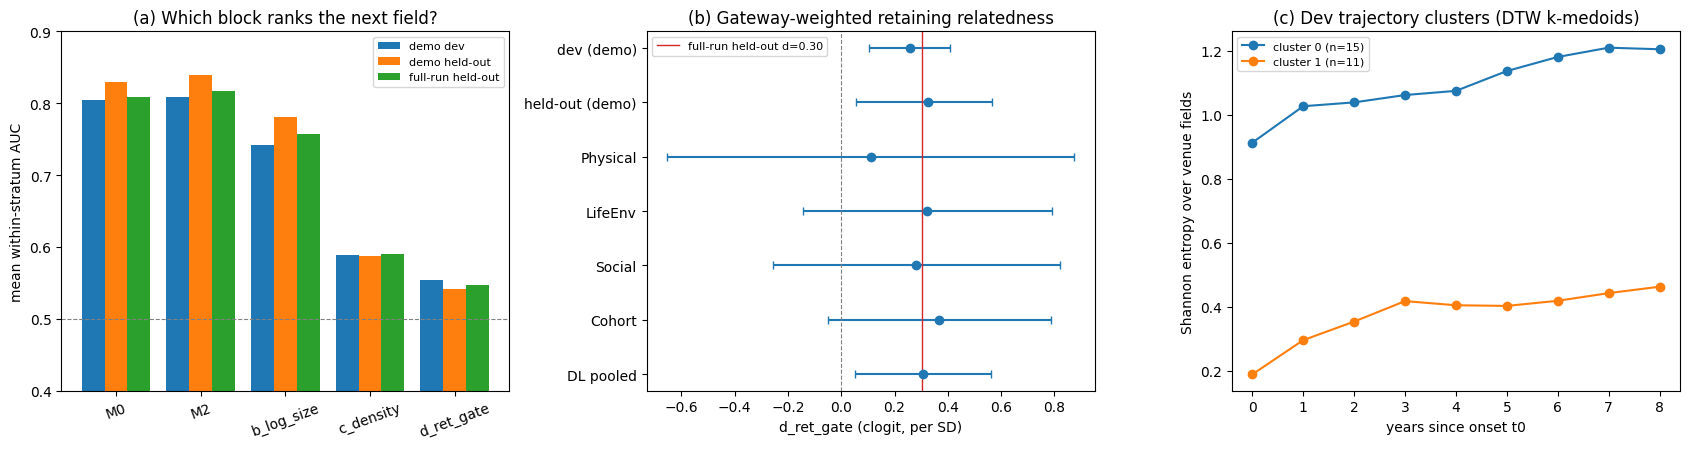

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) within-stratum AUC per block / single regressor: demo dev, demo held-out, full-run held-out
keys = ["M0", "M2", "b_log_size", "c_density", "d_ret_gate"]
x = np.arange(len(keys)); w = 0.27
for i, (lab, vals) in enumerate((("demo dev", [dev["H2"]["auc_within_stratum"][k]["mean"] for k in keys]),
                                 ("demo held-out", [ho["H2_pooled"]["auc_within_stratum"][k]["mean"] for k in keys]),
                                 ("full-run held-out", [ref["heldout_auc"][k] for k in keys]))):
    axes[0].bar(x + (i - 1) * w, vals, w, label=lab)
axes[0].axhline(0.5, color="grey", lw=0.8, ls="--")
axes[0].set_xticks(x, keys, rotation=20); axes[0].set_ylim(0.4, 0.9); axes[0].set_ylabel("mean within-stratum AUC")
axes[0].set_title("(a) Which block ranks the next field?"); axes[0].legend(fontsize=8)

# (b) d_ret_gate forest: pooled dev / held-out, per held-out group, DL pool
lab, b, lo, hi = [], [], [], []
for name, r in (("dev (demo)", dev["H2"]), ("held-out (demo)", ho["H2_pooled"])):
    lab.append(name); b.append(r["models"]["M2"]["coef"]["d_ret_gate"]); lo.append(r["boot_d"]["ci"][0]); hi.append(r["boot_d"]["ci"][1])
for g, v in ho["H2_per_group"].items():
    if "d" in v:
        lab.append(g); b.append(v["d"]); lo.append(v["d"] - 1.96 * v["se"]); hi.append(v["d"] + 1.96 * v["se"])
if "b" in ho["H2_DL_pooled"]:
    lab.append("DL pooled"); b.append(ho["H2_DL_pooled"]["b"]); lo.append(ho["H2_DL_pooled"]["ci"][0]); hi.append(ho["H2_DL_pooled"]["ci"][1])
y = np.arange(len(lab))[::-1]
axes[1].errorbar(b, y, xerr=[np.clip(np.array(b) - np.array(lo), 0, None), np.clip(np.array(hi) - np.array(b), 0, None)], fmt="o", capsize=3)
axes[1].axvline(0, color="grey", lw=0.8, ls="--"); axes[1].axvline(ref["heldout_d"], color="C3", lw=1, label=f'full-run held-out d={ref["heldout_d"]:.2f}')
axes[1].set_yticks(y, lab); axes[1].set_xlabel("d_ret_gate (clogit, per SD)"); axes[1].set_title("(b) Gateway-weighted retaining relatedness")
axes[1].legend(fontsize=8)

# (c) dev trajectory cluster means: entropy H by age
for c, s in dev["trajectories"]["cluster_mean_series"].items():
    axes[2].plot(range(len(s["H"])), s["H"], marker="o", label=f"cluster {c} (n={dev['trajectories']['cluster_sizes'][int(c)]})")
axes[2].set_xlabel("years since onset t0"); axes[2].set_ylabel("Shannon entropy over venue fields")
axes[2].set_title("(c) Dev trajectory clusters (DTW k-medoids)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()